In [1]:
import os
import shutil
import librosa
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import unicodedata
import warnings
import torch
import soundfile as sf

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTENC

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, StratifiedGroupKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score,classification_report, make_scorer, f1_score, precision_score, recall_score, roc_auc_score, fbeta_score
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

!pip install openai-whisper
!pip install Levenshtein
!pip install jiwer
!pip install noisereduce

import noisereduce as nr
import whisper
import Levenshtein
import jiwer



# Conectem amb el google DRIVE

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print(os.listdir("/content/drive/MyDrive"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Classroom', 'DNI (2).pdf', 'FOTO TIPO CARNÉ.pdf', 'Colab Notebooks', 'cinema-4153289_1280.webp', '6024616_071a_2.webp', '0_Zvgdcuol9Wq93lRl.png', 'bovw_image_example.jpg', 'kf_dataqualitybestpractices_oct-22.jpg', 'Guion presentacion.gdoc', 'Captura de pantalla 2024-12-14 140935.png', 'Captura de pantalla 2024-12-14 142139.png', 'esctriptura.pdf', 'IMG_1480.HEIC', 'IMG_1479.HEIC', 'IMG_1481.HEIC', 'Actividad Opcional 1.gdoc', 'Actividad Opcional 2.gdoc', 'IMG_1532.HEIC', 'IMG_1533.HEIC', 'Actividad Opcional 3.gdoc', 'HECTOR: Bon dia (presentacio grup i noms).gdoc', 'Entrega opcional.gdoc', 'IMG_1598.HEIC', 'IMG_1597.HEIC', 'Dependencies.gdoc', 'Guardados de la aplicación Google', 'CV-DAVID_ARAUJO.pdf', 'IMG_1657.HEIC', 'Entrega opcional 6.gdoc', 'IMG_1751.HEIC', 'IMG_1754.HEIC', 'IMG_1757.HEIC', 'IMG_1755.HEIC', 'IMG_1753.HEIC', 'IMG_1756.HEIC', 'IMG_1752

# PATHS

In [3]:
audio_folder="/content/drive/MyDrive/TFG/audios_castella"
output_path="/content/drive/MyDrive/TFG/audios_castella_unificats"
storage_path="/content/drive/MyDrive/TFG/transcripcions.json"
storage_path_2="/content/drive/MyDrive/TFG/transcripcions_2.json"
storage_path_3="/content/drive/MyDrive/TFG/embeddings.json"
storage_xgb="/content/drive/MyDrive/modelo_xgb.pkl"
storage_rf="/content/drive/MyDrive/modelo_rf.pkl"
storage_svm="/content/drive/MyDrive/modelo_svm.pkl"
storage_knn="/content/drive/MyDrive/modelo_knn.pkl"
storage_lm="/content/drive/MyDrive/modelo_lr.pkl"
storage_lgbm="/content/drive/MyDrive/modelo_lgbm.pkl"

In [ ]:
output_path="/content/drive/MyDrive/TFG/audios_castella_unificats_nr"
storage_path="/content/drive/MyDrive/TFG/transcripcions_nr.json"
storage_path_2="/content/drive/MyDrive/TFG/transcripcions_2_nr.json"
storage_path_3="/content/drive/MyDrive/TFG/embeddings_nr.json"
storage_xgb="/content/drive/MyDrive/modelo_xgb_nr.pkl"
storage_rf="/content/drive/MyDrive/modelo_rf_nr.pkl"
storage_svm="/content/drive/MyDrive/modelo_svm_nr.pkl"
storage_knn="/content/drive/MyDrive/modelo_knn_nr.pkl"
storage_lm="/content/drive/MyDrive/modelo_lr_nr.pkl"
storage_lgbm="/content/drive/MyDrive/modelo_lgbm_nr.pkl"

#Reorganitzem tots el audios en una carpeta

In [ ]:
def neteja_text(text):
    text = text.lower()
    text = unicodedata.normalize('NFD', text)
    text = ''.join(c for c in text if unicodedata.category(c) != 'Mn')

    text = text.replace(" ", "_")

    text = re.sub(r'[^a-z0-9_]', '', text)

    return text

os.makedirs(output_path, exist_ok=True)

contador = 0

for escola in os.listdir(audio_folder):
    escola_path = os.path.join(audio_folder, escola)

    for classe in os.listdir(escola_path):
        classe_path = os.path.join(escola_path, classe)

        for audio in os.listdir(classe_path):
            old_file = os.path.join(classe_path, audio)

            name, ext = os.path.splitext(audio)

            name_clean = neteja_text(name)
            escola_clean = neteja_text(escola)
            classe_clean = neteja_text(classe)

            new_name = f"{name_clean}_{escola_clean}_{classe_clean}_{contador:04d}{ext}"

            new_file = os.path.join(output_path, new_name)

            shutil.copy2(old_file, new_file)

            contador += 1

In [ ]:
def neteja_text(text):
    text = text.lower()
    text = unicodedata.normalize('NFD', text)
    text = ''.join(c for c in text if unicodedata.category(c) != 'Mn')

    text = text.replace(" ", "_")

    text = re.sub(r'[^a-z0-9_]', '', text)

    return text


os.makedirs(output_path, exist_ok=True)

contador = 0

for escola in os.listdir(audio_folder):

    escola_path = os.path.join(audio_folder, escola)

    for classe in os.listdir(escola_path):

        classe_path = os.path.join(escola_path, classe)

        for audio_file in os.listdir(classe_path):

            old_file = os.path.join(classe_path, audio_file)

            name, ext = os.path.splitext(audio_file)

            name_clean = neteja_text(name)
            escola_clean = neteja_text(escola)
            classe_clean = neteja_text(classe)

            new_name = (
                f"{name_clean}_"
                f"{escola_clean}_"
                f"{classe_clean}_"
                f"{contador:04d}.wav"
            )

            new_file = os.path.join(output_path, new_name)

            try:
                audio, sr = librosa.load(old_file, sr=None)

                audio_denoised = nr.reduce_noise(
                    y=audio,
                    sr=sr,
                    prop_decrease=0.8
                )

                sf.write(new_file, audio_denoised, sr)

                contador += 1

            except Exception as e:
                print(f"Error procesando {old_file}: {e}")

/tmp/ipykernel_2381/2253550367.py:45: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(old_file, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_2381/2253550367.py:45: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(old_file, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_2381/2253550367.py:45: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(old_file, sr=None)
/usr/local/lib/python3.12/dist-pa

# Definim un mateix nom de llengua

In [4]:
map_llengua={
    "castellano": "castella",
    "espanol": "castella",
    "espanyol": "castella",
    "refeno_arab": "rifeny"
}

# Explorem els audios

### Llengües maternes

In [5]:
def obtenir_llengua(l1_match,mapa_llengues):

  l1 = l1_match.group(1) if l1_match else "No especificat"
  l1=l1.strip("_")
  l1=l1.replace("_i_","_").replace("_y_","_")
  l1=mapa_llengues.get(l1,l1)
  return l1


warnings.filterwarnings("ignore")
results=[]
l1_regex = r"llm_+(.+?)(?:_\d+)?_escola"
audio_no_trobat=[]
diselxia=0

for audio in os.listdir(output_path):
  exemple=os.path.join(output_path, audio)

  #Obtenim el curs
  parts=audio.split("_")
  classe_audio=parts[-2]
  curs=classe_audio[0]

  #obtenim la duracio de l'audio
  y,sr=librosa.load(os.path.join(output_path, audio), sr=16000)
  duration=librosa.get_duration(y=y, sr=sr)

  #obtenim la llengua materna
  l1_match = re.search(l1_regex, audio)

  if not l1_match:
    audio_no_trobat.append(audio)
    continue

  l1=obtenir_llengua(l1_match,map_llengua)

  #Mirem si te dislexia
  dislexia=1 if parts[0]=="d" else 0

  results.append({
                  "arxiu": exemple,
                  "duracio": duration,
                  "lm": l1,
                  "curs": curs,
                  "dislexia":dislexia
              })

df_plot = pd.DataFrame(results)
print(df_plot.head())
print(audio_no_trobat) if audio_no_trobat else "S'han trobat totes les llengües dels audios"


                                               arxiu     duracio        lm  \
0  /content/drive/MyDrive/TFG/audios_castella_uni...  109.830438  castella   
1  /content/drive/MyDrive/TFG/audios_castella_uni...   29.350062  castella   
2  /content/drive/MyDrive/TFG/audios_castella_uni...   56.981812  castella   
3  /content/drive/MyDrive/TFG/audios_castella_uni...   62.322375  castella   
4  /content/drive/MyDrive/TFG/audios_castella_uni...   40.727812    catala   

  curs  dislexia  
0    2         0  
1    4         0  
2    4         0  
3    2         0  
4    4         0  


"S'han trobat totes les llengües dels audios"

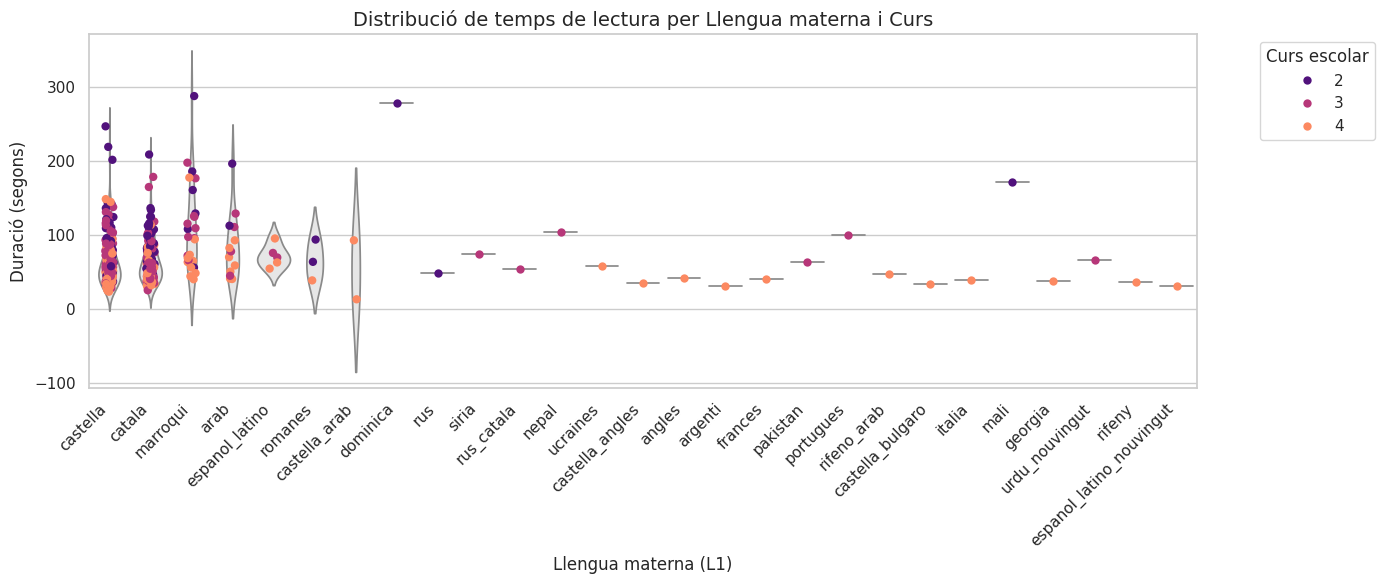

In [6]:
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

course_order=sorted(df_plot["curs"].unique())
order=df_plot["lm"].value_counts().index
sns.violinplot(x='lm', y='duracio', data=df_plot, order=order, inner=None, color=".9")
sns.stripplot(x='lm', y='duracio', data=df_plot, hue='curs',hue_order=course_order,order=order ,size=6, jitter=True, palette="magma")

plt.title('Distribució de temps de lectura per Llengua materna i Curs', fontsize=14)
plt.xlabel('Llengua materna (L1)', fontsize=12)
plt.ylabel('Duració (segons)', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.legend(title='Curs escolar', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Dislèxia

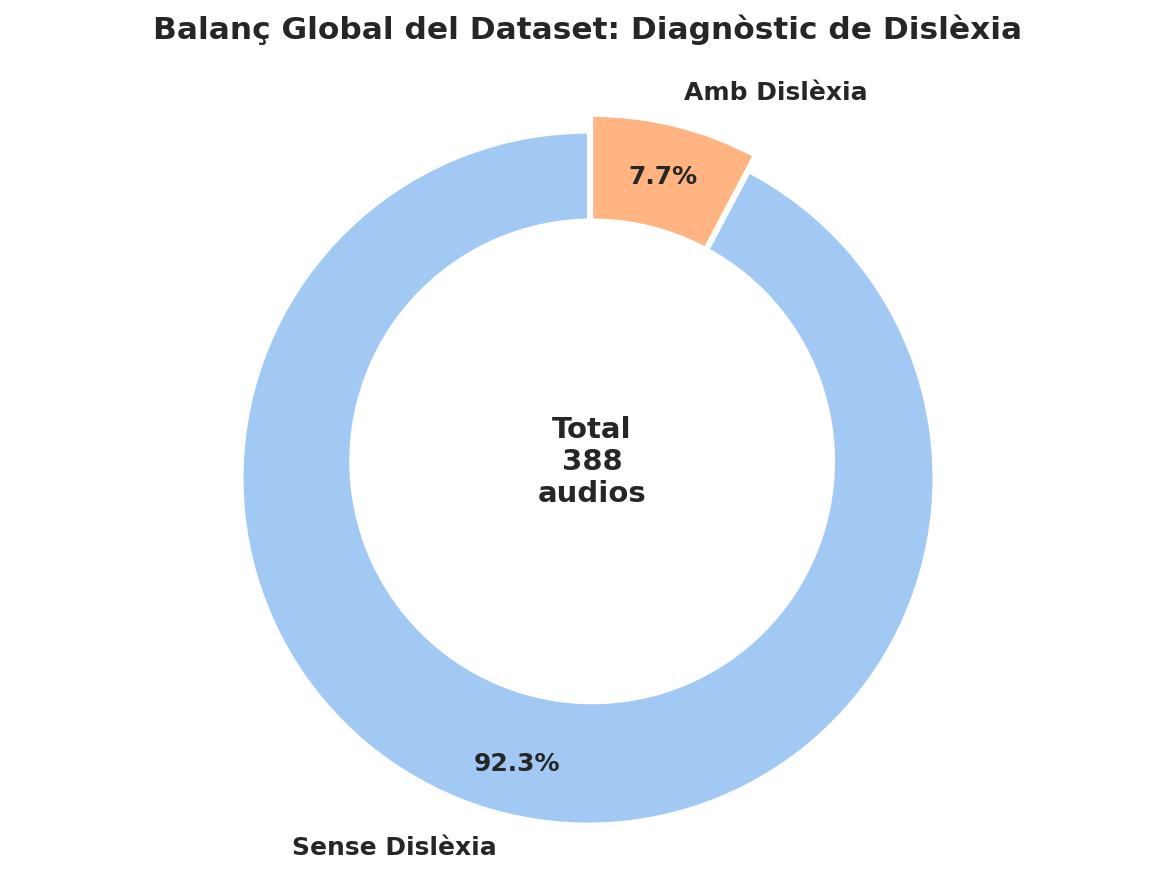

In [7]:
def plot_balance_global(df):
    counts = df['dislexia'].value_counts()
    labels = ['Sense Dislèxia', 'Amb Dislèxia']
    colors = sns.color_palette('pastel')[0:2]

    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        pctdistance=0.85,
        explode=[0.05, 0],
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )

    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    total = len(df)
    plt.text(0, 0, f'Total\n{total}\naudios', ha='center', va='center', fontsize=14, fontweight='bold')

    plt.title('Balanç Global del Dataset: Diagnòstic de Dislèxia', fontsize=15, pad=20, fontweight='bold')

    plt.axis('equal')
    plt.tight_layout()
    plt.show()

plot_balance_global(df_plot)

### Alumnes i dislèxia per curs

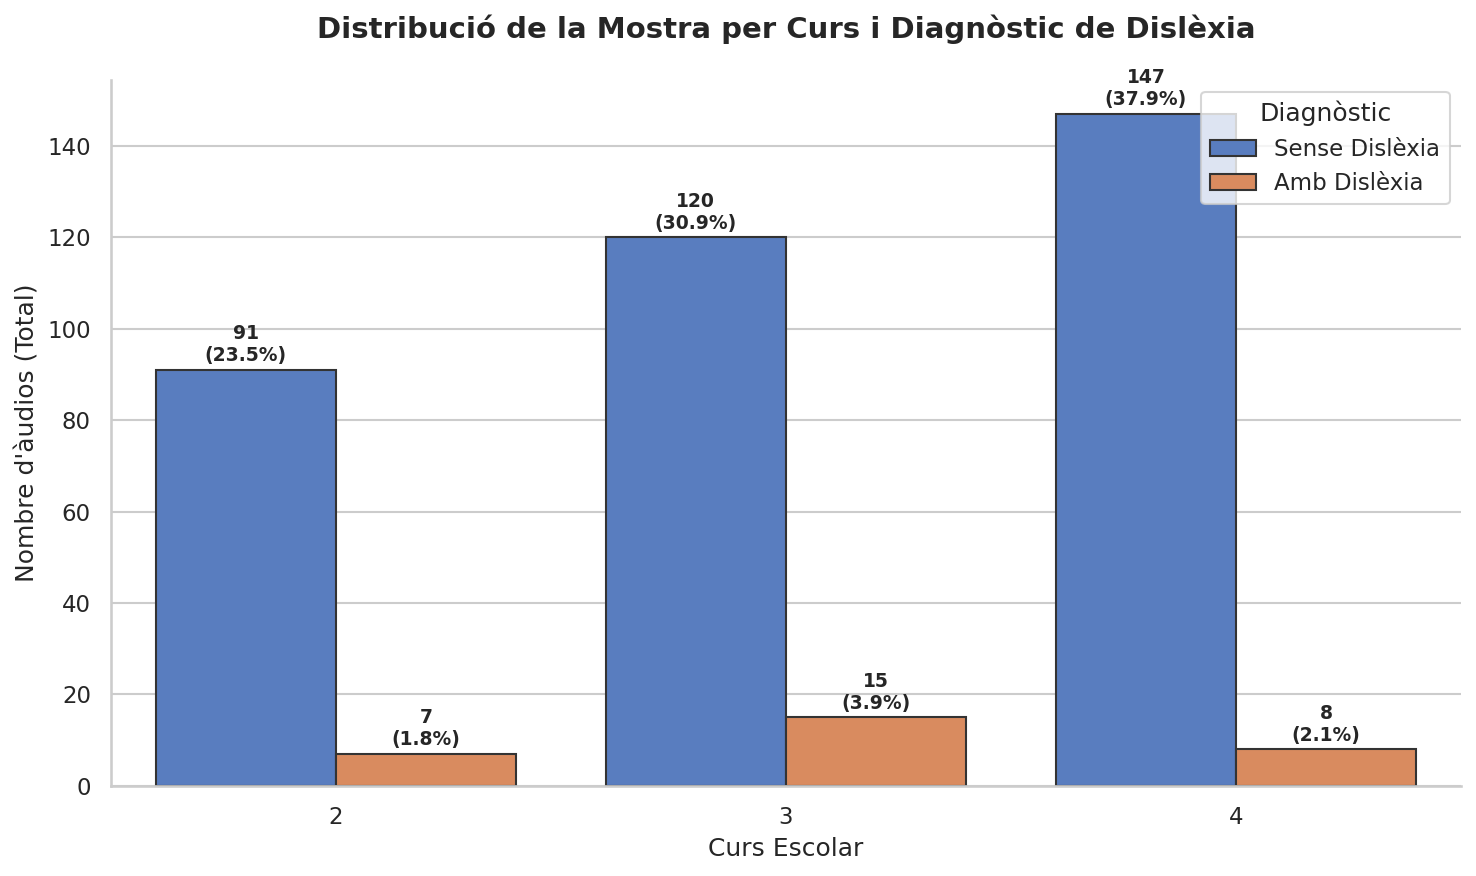

In [8]:
def plot_distribucion_dislexia(df):
    plt.figure(figsize=(10, 6))
    course_order=sorted(df["curs"].unique())
    ax = sns.countplot(data=df, x='curs', hue='dislexia',order=course_order, edgecolor="0.2")

    plt.title('Distribució de la Mostra per Curs i Diagnòstic de Dislèxia', fontsize=14, pad=20, fontweight='bold')
    plt.xlabel('Curs Escolar', fontsize=12)
    plt.ylabel("Nombre d'àudios (Total)", fontsize=12)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Sense Dislèxia', 'Amb Dislèxia'], title='Diagnòstic', loc='upper right')

    total_audios = len(df)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}\n({(height/total_audios*100):.1f}%)',
                        (p.get_x() + p.get_width() / 2., height),
                        ha = 'center', va = 'center',
                        xytext = (0, 12),
                        textcoords = 'offset points',
                        fontsize=9, fontweight='bold')

    sns.despine()
    plt.tight_layout()
    plt.show()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150
plot_distribucion_dislexia(df_plot)

#Creació Dataset

In [ ]:
model=whisper.load_model("base")


for audio in results:
  arxiu=audio["arxiu"]
  print(f"Processant audio {arxiu}")

  y,sr=librosa.load(arxiu, sr=16000)  #Carreguem audio a 16000 Hz encara, que el whisper ja ho fa internament
  output=model.transcribe(y, task="transcribe", fp16=False)

  logprobs=[segment["avg_logprob"] for segment in output["segments"]]   #Confianca whisper (pronunciacio)
  confianca_mitjana=np.mean(logprobs)
  confianca_std=np.std(logprobs)

  ritmes_segment=[segment["end"]-segment["start"] for segment in output["segments"]]   #ritmes de cada segment

  final=output["segments"][-1]["end"]
  inici=output["segments"][0]["start"]   #Inici
  duracio=final-inici

  ritme_std=np.std(ritmes_segment)               #Desviacio dels segments (canvis de ritme)
  temps_parla=np.sum(ritmes_segment)             #Temps de silenci durant la lectura
  silencis=(duracio-temps_parla)/duracio         #Silencis en els audios normalitzats

  dades_whisper={
                  "text": output["text"].strip(),        #Text transcrit
                  "confianca_mitjana":confianca_mitjana, #Confianca mitjana whisper de l'extraccio
                  "confianca_std":confianca_std,         #Desviacio mitjana whisper de l'extraccio
                  "duracio_parla": duracio,              #Duracio de la lectura
                  "ritme_std":ritme_std,                 #Canvis de ritme
                  "silencis":silencis,                   #Silencis durant la lectura
                  }
  audio.update(dades_whisper)


with open(storage_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=4)


In [ ]:
with open (storage_path, 'r', encoding='utf-8') as f:
  results=json.load(f)
print(sum([1 for result in results]))

###Ground Truth

In [ ]:
def neteja(text):
  text=text.lower()
  text = re.sub(r'[^\w\s]', '', text)

  ###DUBTE
  titol=["los","ocapis"]
  paraules=text.split()
  if paraules[0:2]==titol and paraules[2:4]==titol:
    return "".join(paraules[2:])

  return text

with open("/content/drive/MyDrive/TFG/Los_okapis.txt","r",encoding="utf-8") as f:
  gt_brut=f.read()

GT=neteja(gt_brut)
print(GT)
print(len(GT))

In [ ]:
with open(storage_path, 'r', encoding='utf-8') as f:
  results=json.load(f)
print(results[0])

for result in results:
  text_net=neteja(result["text"])
  ref_GT=GT.split()
  ref_text=text_net.split()
  result["cer"]=Levenshtein.distance(GT,text_net)/len(GT)           #cer
  result["wer"]=jiwer.wer(GT,text_net)                              #wer
  result["velocitat"]=len(ref_text)/result["duracio"]               #velocitat: paraules/segon
  result["ratio"]=len(ref_text)/len(ref_GT)                         #ratio de paraules amb el GT

df=pd.DataFrame(results)
features=["arxiu","confianca_mitjana",
          "confianca_std","ritme_std","silencis",
          "cer","wer","velocitat","ratio","curs","lm","dislexia"]


df_1=df[features]
df_1.head(30)

### Representacions diagrames de MEL

Processant audio /content/drive/MyDrive/TFG/audios_castella_unificats_nr/nuria_8__los_okapis_castellano__llm__catala_escola_1_2a_0000.wav
Processant audio /content/drive/MyDrive/TFG/audios_castella_unificats_nr/joan8__los_okapis_castellano__llm__castellano_escola_1_2a_0001.wav
Processant audio /content/drive/MyDrive/TFG/audios_castella_unificats_nr/ever8__los_okapis_castellano__llm__castellano_escola_1_2a_0002.wav
Processant audio /content/drive/MyDrive/TFG/audios_castella_unificats_nr/victor7__los_okapis_castellano__llm__castellano_escola_1_2a_0003.wav
Processant audio /content/drive/MyDrive/TFG/audios_castella_unificats_nr/bertar8__los_okapis_castellano__llm__castellano_escola_1_2a_0004.wav
Processant audio /content/drive/MyDrive/TFG/audios_castella_unificats_nr/polf7__los_okapis_castellano__llm__catala_escola_1_2a_0005.wav
Processant audio /content/drive/MyDrive/TFG/audios_castella_unificats_nr/lolad7__los_okapis_castellano__llm__castellano_escola_1_2a_0006.wav
Processant audio /con

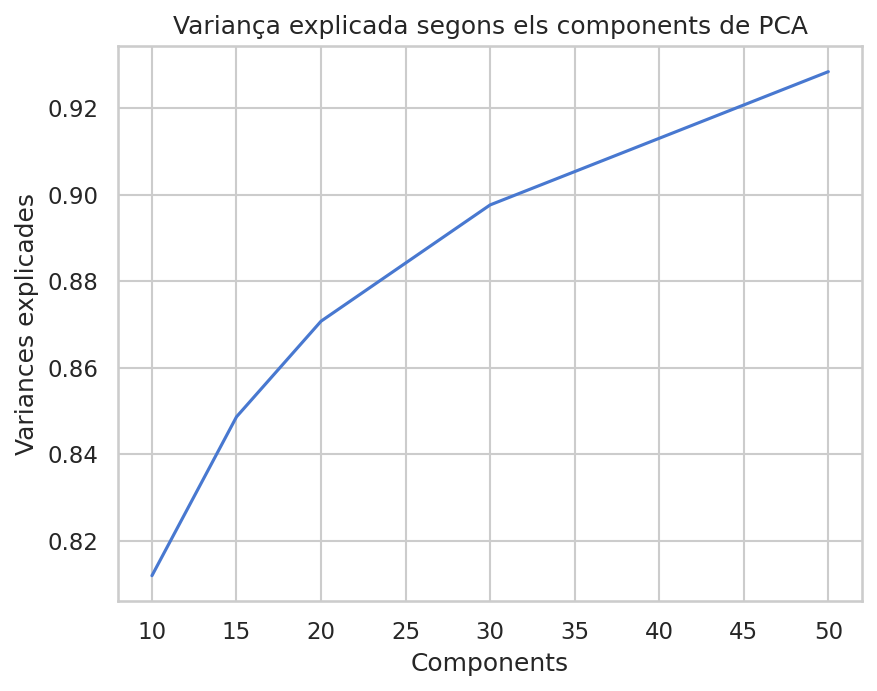

In [ ]:
def complete_embedding(ruta_audio, model):
  audio = whisper.load_audio(ruta_audio)

  all_embeddings = []
  all_weights = []

  chunk = 16000 * 15  #  chunks de 15s

  for i in range(0, len(audio), chunk):

    chunk_audio = audio[i:i+chunk]
    real_length = len(chunk_audio)

    chunk_audio = whisper.pad_or_trim(chunk_audio)

    mel = whisper.log_mel_spectrogram(chunk_audio).to(model.device).unsqueeze(0)

    with torch.no_grad():
        emb = model.encoder(mel)

    emb = emb.squeeze(0).cpu().numpy()

    mean = emb.mean(axis=0)
    std = emb.std(axis=0)  # variació de l'embedding

    #1024 dimensions
    chunk_embedding = np.concatenate([mean,std])

    all_embeddings.append(chunk_embedding)
    all_weights.append(real_length)

  final_embedding = np.average(all_embeddings, axis=0, weights=all_weights)

  return final_embedding

model=whisper.load_model("base")
embeddings_audio=[]
variances=[]
components=[10,15,20,30,50]
for result in results:
  print(f"Processant audio {result['arxiu']}")
  embeddings_audio.append(complete_embedding(result["arxiu"],model))
embeddings_audio=np.array(embeddings_audio)

for component in components:
  pca=PCA(n_components=component)
  embeddings_pca=pca.fit_transform(embeddings_audio)
  varianca=np.sum(pca.explained_variance_ratio_)
  variances.append(varianca)
  print(f"Components: {component}, Varianca: {varianca}")

plt.plot(components,variances)
plt.xlabel("Components")
plt.ylabel("Variances explicades")
plt.title("Variança explicada segons els components de PCA")
plt.show()


In [ ]:
for i,result in enumerate(results):
  result["embeddings"]=embeddings_audio[i].tolist()

with open(storage_path_2,"w",encoding="utf-8") as f:
  json.dump(results, f,ensure_ascii=False, indent=4)

#DataFrame

#####DataFrame1

In [9]:
with open(storage_path_2, 'r', encoding='utf-8') as f:
  results=json.load(f)

features=["arxiu","confianca_mitjana",
          "confianca_std","ritme_std","silencis",
          "cer","wer","velocitat","ratio","curs","lm","embeddings","dislexia"]

df=pd.DataFrame(results)
df=df[features]
df.head(30)

,arxiu,confianca_mitjana,confianca_std,ritme_std,silencis,cer,wer,velocitat,ratio,curs,lm,embeddings,dislexia
0,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.708783,8.654803e-02,2.759990,1.787017e-02,0.154762,0.373333,0.746605,1.093333,2,castella,"[-0.4438109599836692, -0.32708389343886063, 0....",0
1,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.399684,5.551115e-17,0.687184,0.000000e+00,0.138095,0.253333,2.521289,0.986667,4,castella,"[-0.18758949891331952, -0.2463426143121691, -0...",0
2,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.260362,6.503376e-02,3.201562,0.000000e+00,0.085714,0.133333,1.386407,1.053333,4,castella,"[-0.31042770204634307, -0.4381089753776621, -0...",0
3,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.243936,2.054560e-02,8.377798,1.612903e-02,0.042857,0.093333,1.219466,1.013333,2,castella,"[-0.43696759291471604, -0.4226303034512374, 0....",0
4,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.207233,2.529987e-02,2.134375,0.000000e+00,0.071429,0.160000,1.841493,1.000000,4,catala,"[-0.3681662809972816, -0.47386205245636115, 0....",0
5,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.226146,1.813243e-02,1.195229,0.000000e+00,0.042857,0.080000,1.745935,1.000000,4,catala,"[-0.3519398769651576, -0.49638821578131825, -0...",0
6,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.550943,2.903898e-01,11.578394,2.448580e-02,0.150000,0.266667,0.991580,1.080000,2,catala,"[-0.40563093192293675, -0.3937799941511767, 0....",0
7,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.450558,1.778927e-03,1.030158,0.000000e+00,0.128571,0.293333,1.888659,1.013333,4,arab,"[-0.23948464865567257, -0.39764303435600795, -...",0
8,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.375613,3.639527e-02,1.606207,1.077586e-02,0.066667,0.146667,1.988092,0.986667,3,catala,"[-0.30209914490123224, -0.4971496904968192, -0...",0
9,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.243850,1.067812e-01,3.685557,0.000000e+00,0.116667,0.200000,1.579357,1.093333,3,castella,"[-0.37571905234813807, -0.468523158621594, 0.0...",0


# Preprocessing

### Ordinal Encoding

In [10]:
def determinar_llengua(llengua):
  if "_" in llengua:
    if "latino" in llengua:
      return "castella"
    return "altres"
  else:
    if any(x in llengua for x in ["castella", "argenti", "dominica"]):
      return "castella"
    elif "catala" in llengua:
      return "catala"
    else:
      return "altres"

df["lm_grup"]=df["lm"].apply(determinar_llengua)

df["lm_"] = df["lm_grup"].map({
    "castella": 0,
    "catala": 1,
    "altres": 2
})

print(df[["lm_"]].head(10))

df = df.drop(columns=["lm_grup"])
df=df.drop(columns=["lm"])

   lm_
0    0
1    0
2    0
3    0
4    1
5    1
6    1
7    2
8    1
9    0


###Normalization 1

In [11]:
#Transformem els embeddings en llista
emb_df=pd.DataFrame(df["embeddings"].tolist(), index=df.index)
emb_df.columns=[f"emb_{i}" for i in range (emb_df.shape[1])]
df=pd.concat([df,emb_df], axis=1)
df=df.drop(columns=["embeddings"])

### Correlation matrix

In [12]:
def correlation_matrix(df,features_corr):

  corr_matrix = df[features_corr].apply(pd.to_numeric).corr()

  plt.figure(figsize=(12, 10))


  sns.heatmap(
      corr_matrix,
      annot=True,
      fmt=".2f",
      cmap='RdBu_r',
      center=0,
      linewidths=.5,
      cbar_kws={"shrink": .8}
  )

  plt.title('Matriu de Correlació: Features NLP i L1 vs Dislèxia', fontsize=16, pad=20)
  plt.xticks(rotation=45, ha='right')
  plt.show()

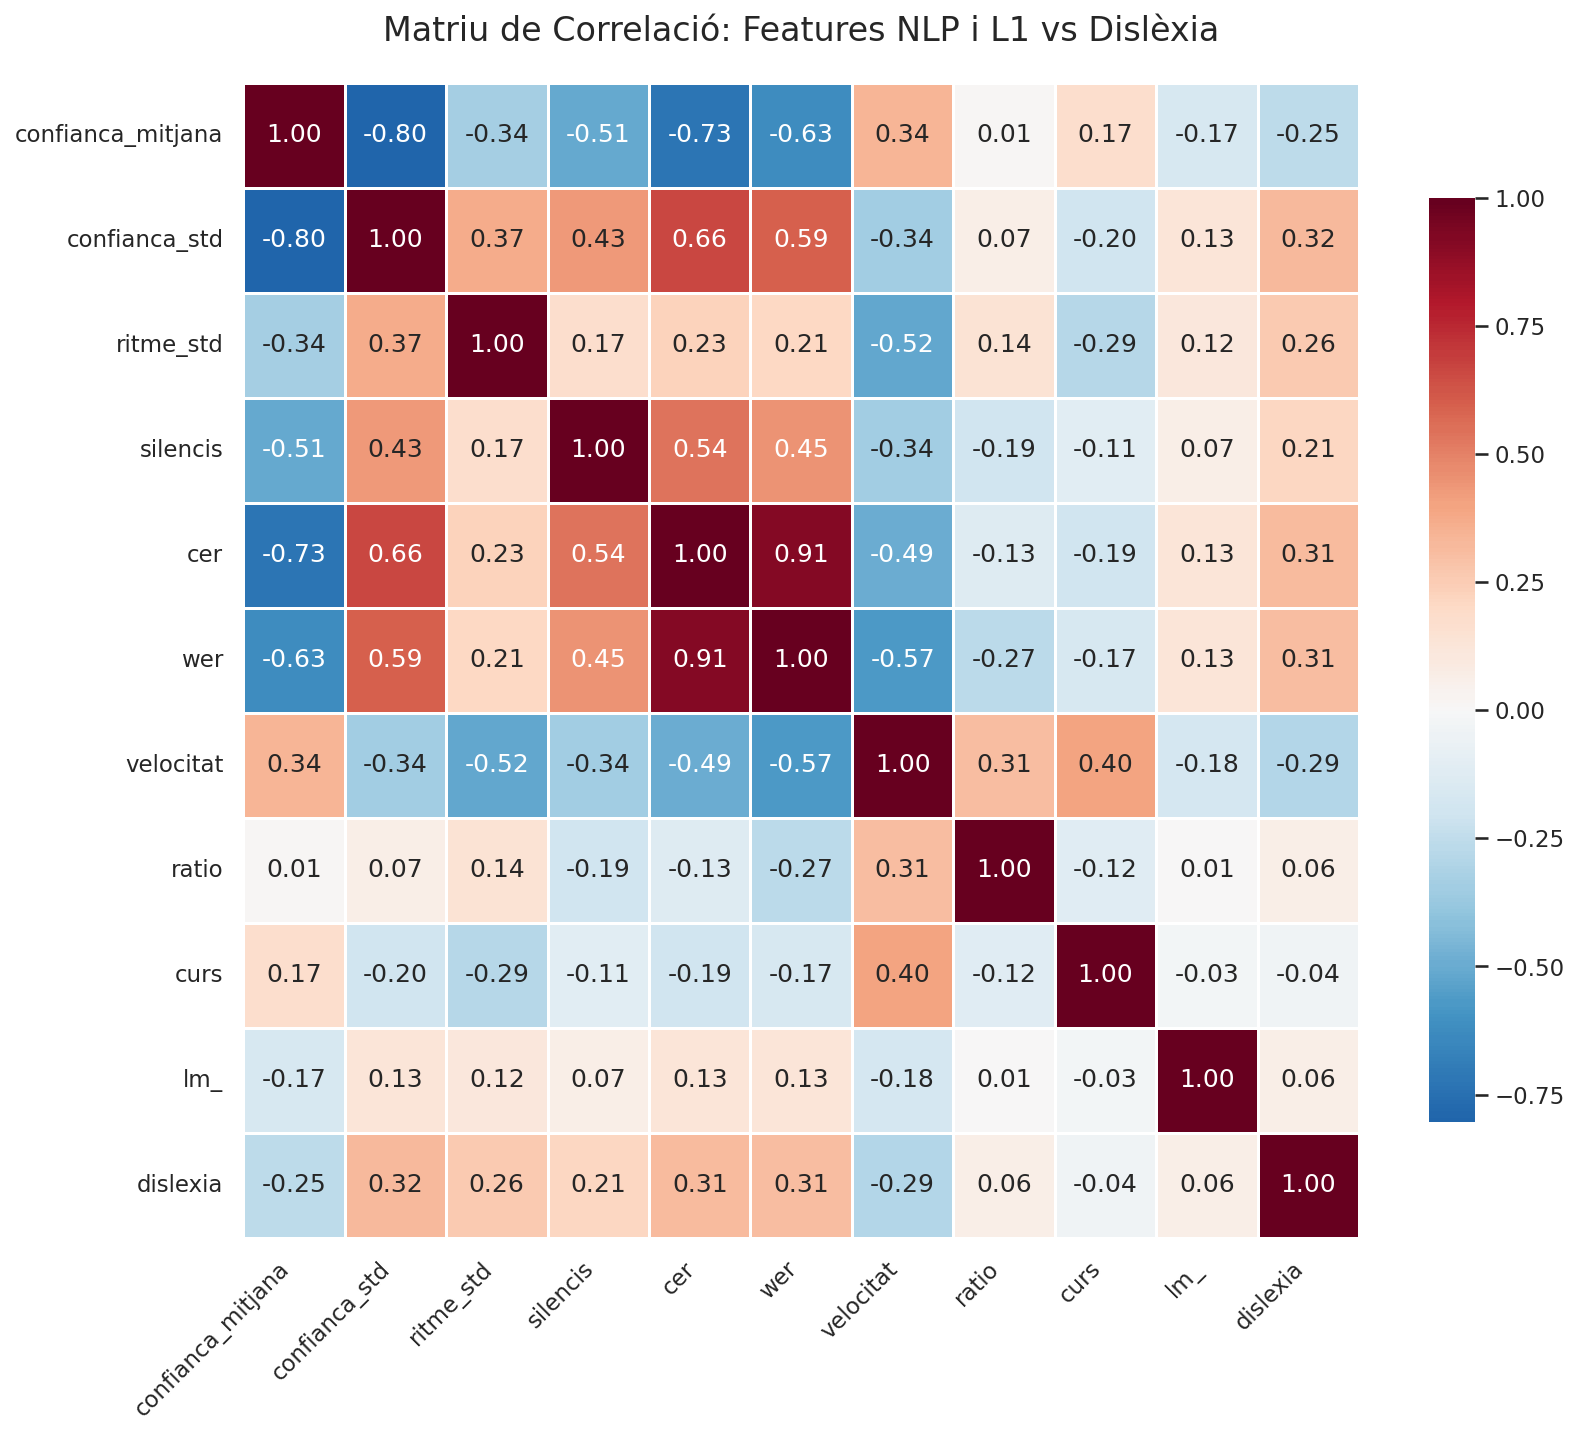

In [13]:
features_corr = [
    "confianca_mitjana", "confianca_std", "ritme_std", "silencis",
    "cer", "wer", "velocitat", "ratio", "curs",
    "lm_", "dislexia"
]
features_emb=[col for col in df.columns if "emb_" in col]+["dislexia"]

correlation_matrix(df,features_corr)
#correlation_matrix(df,features_emb)


### Oversampling + Normalization 2 -> VISUALITZACIÓ

In [14]:
def split(df,columns_no_train):
  #Estratifiquem per dislexia i curs
  df["stratification"]=df["dislexia"].astype(str)+"_"+df["curs"].astype(str)
  X=df.drop(columns=columns_no_train)
  y=df["dislexia"]

  X_train,X_test,y_train,y_test=train_test_split(
      X,y,
      test_size=0.2,
      random_state=42,
      stratify=df["stratification"]
  )
  return X_train,X_test,y_train,y_test


In [15]:
from imblearn.over_sampling import SMOTENC

columns_no_train=["arxiu","dislexia","stratification"]+[column for column in df.columns if "emb_" in column]
X_train,X_test,y_train,y_test=split(df,columns_no_train)


#Normalization without embeddings
standard_scaler=StandardScaler()
columns_to_normalize_not_emb=[
    "confianca_mitjana", "confianca_std", "ritme_std", "silencis",
    "cer", "wer", "velocitat", "ratio"
]
X_train_norm=X_train.copy()
X_test_norm=X_test.copy()
X_train_norm[columns_to_normalize_not_emb]=standard_scaler.fit_transform(X_train[columns_to_normalize_not_emb])
X_test_norm[columns_to_normalize_not_emb]=standard_scaler.transform(X_test[columns_to_normalize_not_emb])


#Oversampling
#categorical_index=[X_train.columns.get_loc(column) for column in cols_bool]
categorical_index=[X_train.columns.get_loc(column) for column in X_train.columns if "lm_" in column]
smote=SMOTENC(categorical_features=categorical_index,random_state=42)
X_train_res,y_train_res=smote.fit_resample(X_train_norm,y_train)

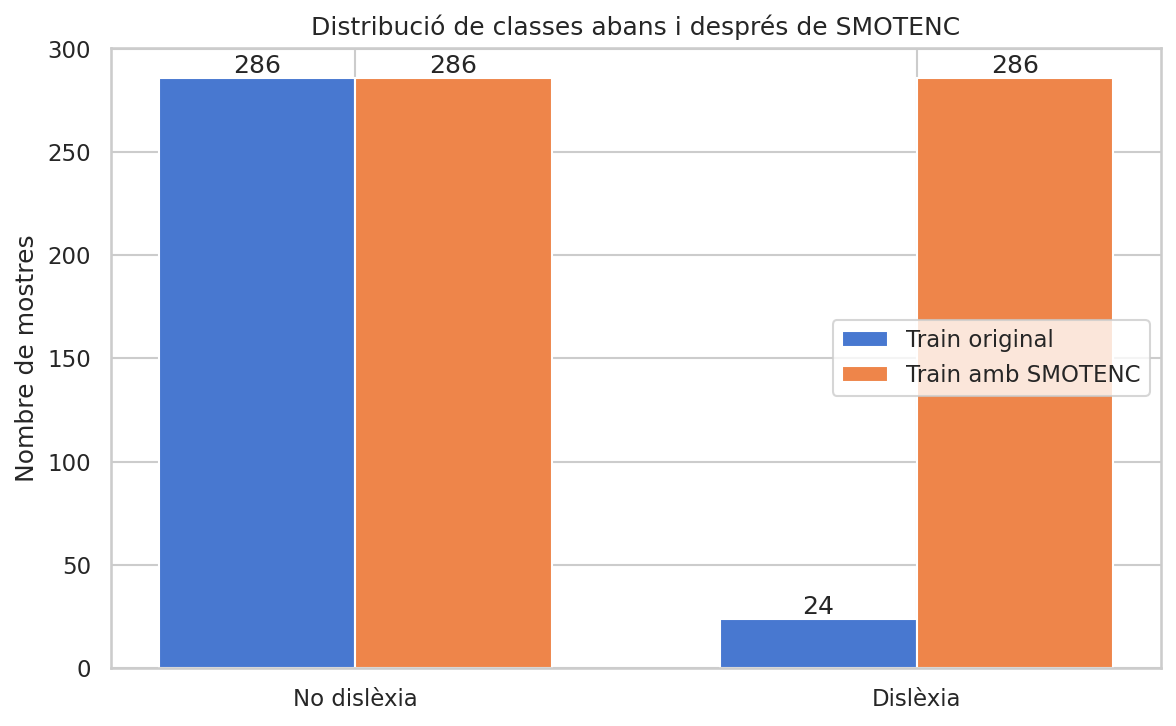

In [16]:
original_counts = y_train.value_counts().sort_index()
resampled_counts = y_train_res.value_counts().sort_index()

labels = ['No dislèxia', 'Dislèxia']

before = [original_counts.get(0, 0), original_counts.get(1, 0)]
after = [resampled_counts.get(0, 0), resampled_counts.get(1, 0)]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar([i - width/2 for i in x], before, width, label='Train original')
bars2 = plt.bar([i + width/2 for i in x], after, width, label='Train amb SMOTENC')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{int(height)}',
                 ha='center', va='bottom')

plt.xticks(x, labels)
plt.ylabel('Nombre de mostres')
plt.title('Distribució de classes abans i després de SMOTENC')
plt.legend()

plt.tight_layout()
plt.show()

#No s'utilitzarà aquest train y test set, es fa això per visualitzar

# Training

In [17]:
rf = RandomForestClassifier(random_state=42)
xgb=XGBClassifier(random_state=42)
svm=SVC(random_state=42)
knn=KNeighborsClassifier()
lm=LogisticRegression(random_state=42)
lgbm=LGBMClassifier(random_state=42)

In [18]:
params_grid={

    "param_grid_rf":{
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt'],
    'model__class_weight': [None, 'balanced'] },

    "param_grid_xgb":{
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.8, 0.9],
    'model__scale_pos_weight': [1,11]
},
"param_grid_svm":{
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 0.01, 0.1, 1],
    'model__kernel': ['rbf', 'linear'],
    'model__class_weight': ['balanced'],
    'model__probability': [True]
},

"param_grid_knn":{
    'model__n_neighbors': [3, 5, 7, 10, 20],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
},

"param_grid_lm":{
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2','l1'],
    'model__class_weight': ['balanced'],
    'model__solver': ['liblinear','lbfgs']
},
"param_grid_lgbm":{
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [7, 15, 31],
    'model__max_depth': [3, 5, -1],
    'model__is_unbalance': [True],
    'model__boost_from_average': [False]
}
}

In [22]:
from sklearn.model_selection import cross_val_predict,StratifiedKFold
class Training:

  def __init__ (self,X_train,y_train,X_test,y_test,groups=None):
    self.X_train=X_train
    self.y_train=y_train
    self.X_test=X_test
    self.y_test=y_test
    self.results={}
    self.groups=groups

  def entrenament(self,pipeline, dict_models, scoring,params_grid,cv):

    def find_best_threshold(y_true, y_probs, beta=2):

      thresholds = np.arange(0.01, 1.0, 0.01)

      best_threshold = 0.5
      best_score = -1

      for t in thresholds:

          y_pred = (y_probs >= t).astype(int)

          score = fbeta_score(y_true, y_pred, beta=beta)

          if score > best_score:
              best_score = score
              best_threshold = t

      return best_threshold, best_score

    for name, model in dict_models.items():
      print(f"Entrenant {name}")

      pipeline.set_params(model=model)
      param_grid_model=params_grid[f"param_grid_{name}"]

      grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid_model,
        cv=cv,
        scoring=scoring,
        refit='f1',
        n_jobs=-1,
        verbose=2
        )

      # Entrenar
      if self.groups is not None:
        grid_search.fit(self.X_train, self.y_train, groups=self.groups)
      else:
        grid_search.fit(self.X_train, self.y_train)
      cv_results=grid_search.cv_results_
      best= grid_search.best_estimator_

      #Millor Threshold

      # OUT-OF-FOLD probabilities
      cv_threshold=StratifiedKFold(
      n_splits=5,
      shuffle=True,
      random_state=42
       )

      oof_probs = cross_val_predict(
          best,
          self.X_train,
          self.y_train,
          cv=cv_threshold,
          method="predict_proba",
          n_jobs=-1
      )[:,1]

      # Find optimal threshold
      best_threshold, best_f2 = find_best_threshold(
          self.y_train,
          oof_probs,
          beta=2
      )

      self.results[name] = {
            "model": best,
            "best_params": grid_search.best_params_,
            "mean_test_f1":cv_results['mean_test_f1'][grid_search.best_index_],
            "std_test_f1": cv_results['std_test_f1'][grid_search.best_index_],
            "mean_test_recall":cv_results['mean_test_recall'][grid_search.best_index_],
            "std_test_recall": cv_results['std_test_recall'][grid_search.best_index_],
            "mean_test_precision":cv_results['mean_test_precision'][grid_search.best_index_],
            "std_test_precision": cv_results['std_test_precision'][grid_search.best_index_],
            "threshold": best_threshold
        }
    return self.results


  def print_results(self):
    for name in self.results.keys():
      print(f"Model: {name}")
      print(f"Best hiperparameters: {self.results[name]['best_params']}")
      print(f"Best mean F1 in CV: {self.results[name]["mean_test_f1"]} ± {self.results[name]["std_test_f1"]}")
      print(f"Best mean Recall in CV: {self.results[name]['mean_test_recall']} ± {self.results[name]['std_test_recall']}")
      print(f"Best mean Precision in CV: {self.results[name]['mean_test_precision']} ± {self.results[name]['std_test_precision']}")
      model = self.results[name]["model"]
      y_test_probs = model.predict_proba(self.X_test)[:, 1]
      y_train_probs = model.predict_proba(self.X_train)[:, 1]
      y_pred=(y_test_probs>=self.results[name]["threshold"]).astype(int)
      y_train_pred=(y_train_probs>=self.results[name]["threshold"]).astype(int)
      print(f"Classification report test de {name} {classification_report(self.y_test, y_pred)}")
      print(f"Classification report train de {name} {classification_report(self.y_train, y_train_pred)}")
    return y_pred,y_test_probs

  def print_results_profund(self):
    tablas_modelos = {}

    for name, info in self.results.items():
        print(f"ANALITZANT MODEL: {name.upper()} amb threshold: {self.results[name]["threshold"]}")

        model_pipeline = info["model"]
        y_probs = model_pipeline.predict_proba(self.X_test)[:, 1]
        y_pred= (y_probs >=self.results[name]["threshold"]).astype(int)

        df_modelo = pd.DataFrame({
            'Realidad': self.y_test.values,
            'Prediccion': y_pred,
            'Prob_Dislexia': y_probs,
            'Error': self.y_test.values != y_pred
        }, index=self.X_test.index)

        tablas_modelos[name] = df_modelo

        solo_dislexicos = df_modelo[df_modelo['Realidad'] == 1]
        dislexicos_modelos=df_modelo[df_modelo["Prediccion"]==1]
        n_modelo=(dislexicos_modelos["Realidad"]==1).sum()
        n_detectados = (solo_dislexicos['Prediccion'] == 1).sum()
        total_dislexicos = len(solo_dislexicos)
        total_predicciones=len(dislexicos_modelos)

        print(f"\n RECALL: Detectats {n_detectados} de {total_dislexicos} nens amb dislexia.")
        print(f"\n PRECISSION: {n_modelo} dislexics eren reals dels {total_predicciones} predits.")

        print("\nDetalle de los niños con dislexia:")
        print(solo_dislexicos)
        print(dislexicos_modelos)

  def plot_metrics(self):
    n_models = len(self.results)
    fig, axes = plt.subplots(n_models, 3, figsize=(18, 5 * n_models))
    if n_models == 1:
      axes = axes.reshape(1, -1)

    for i, (name, info) in enumerate(self.results.items()):
        model = info["model"]
        y_test_probs = model.predict_proba(self.X_test)[:, 1]
        y_pred = (y_test_probs >= self.results[name]["threshold"]).astype(int)

#Confussion matrix

        cm = confusion_matrix(self.y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sa", "Dislèxia"])
        disp.plot(ax=axes[i, 0], cmap='Blues', colorbar=False)
        axes[i, 0].set_title(f"Confusió: {name.upper()}")

#Especificitat
        # tn, fp, fn, tp = cm.ravel()
      # specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
      #
      # axes[i, 0].text(
      #     0.5, -0.15,
      #     f"Especificitat: {specificity:.2f}",
      #     ha='center',
      #     transform=axes[i, 0].transAxes,
      #     fontsize=12
      # )

#ROC curve
        fpr, tpr, _ = roc_curve(self.y_test, y_test_probs)
        roc_auc = auc(fpr, tpr)
        axes[i, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
        axes[i, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[i, 1].set_title(f"ROC: {name.upper()}")
        axes[i, 1].legend(loc="lower right")

#Precission-Recall curve

        prec, rec, _ = precision_recall_curve(self.y_test, y_test_probs)
        avg_prec = average_precision_score(self.y_test, y_test_probs)
        axes[i, 2].plot(rec, prec, color='green', lw=2, label=f'AP = {avg_prec:.2f}')
        axes[i, 2].set_title(f"P-R: {name.upper()}")
        axes[i, 2].legend(loc="lower left")

    plt.tight_layout()
    plt.show()



In [23]:
from imblearn.over_sampling import SMOTE

pca=PCA(n_components=30,random_state=42)

preprocessor=ColumnTransformer(
    transformers=[
        ("scaler",StandardScaler(),columns_to_normalize_not_emb)
    ],
    remainder="passthrough"
)

preprocessor2=StandardScaler()


pipeline=Pipeline([
    ('smote',SMOTENC(categorical_features=categorical_index,random_state=42)),
    ('prep',preprocessor),
    ('model', rf)
])

pipeline2=Pipeline([
    ('prep',preprocessor2),
    ('smote',SMOTE(random_state=42)),
    ('PCA',pca),
    ('model', rf)
])

pipeline3=Pipeline([
    ('prep',preprocessor2),
    ('smote',SMOTE(random_state=42)),
    ('model', rf)
])


cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
cv_groups = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

scoring={"f1":"f1",
         "recall": "recall",
         "precision": "precision"}

dict_models={
    "rf":rf,
    "xgb":xgb,
    "svm":svm,
    "knn":knn,
    "lm":lm,
    "lgbm":lgbm
}

## First Approach
### Training sense embeddings

In [ ]:
training=Training(X_train,y_train,X_test,y_test)
entrenament=training.entrenament(pipeline, dict_models, scoring,params_grid,cv)

Entrenant rf
Fitting 15 folds for each of 48 candidates, totalling 720 fits
Entrenant xgb
Fitting 15 folds for each of 216 candidates, totalling 3240 fits
Entrenant svm
Fitting 15 folds for each of 32 candidates, totalling 480 fits
Entrenant knn
Fitting 15 folds for each of 20 candidates, totalling 300 fits
Entrenant lm
Fitting 15 folds for each of 20 candidates, totalling 300 fits
Entrenant lgbm
Fitting 15 folds for each of 81 candidates, totalling 1215 fits
[LightGBM] [Info] Number of positive: 286, number of negative: 286
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000218 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1381
[LightGBM] [Info] Number of data points in the train set: 572, number of used features: 10
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

In [ ]:
training.print_results()

Model: rf
Best hiperparameters: {'model__class_weight': None, 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best mean F1 in CV: 0.33712261594614534 ± 0.09867730414256753
Best mean Recall in CV: 0.5133333333333334 ± 0.15434449203720302
Best mean Precision in CV: 0.2584192221034326 ± 0.09028110421572097
Classification report test de rf               precision    recall  f1-score   support

           0       0.96      0.76      0.85        72
           1       0.19      0.67      0.30         6

    accuracy                           0.76        78
   macro avg       0.58      0.72      0.57        78
weighted avg       0.91      0.76      0.81        78

Classification report train de rf               precision    recall  f1-score   support

           0       1.00      0.78      0.88       286
           1       0.28      1.00      0.44        24

    accuracy                           0.8

(array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
        1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0]),
 array([0.17910401, 0.18320694, 0.18320694, 0.18320694, 0.50395683,
        0.18320694, 0.18320694, 0.18312823, 0.18320694, 0.18320694,
        0.18755909, 0.18320694, 0.18320694, 0.17910401, 0.20324487,
        0.18320694, 0.25498057, 0.59729714, 0.18755909, 0.18320694,
        0.18320694, 0.27833558, 0.17910401, 0.58195547, 0.18320694,
        0.24131427, 0.18320694, 0.18320694, 0.17910401, 0.71864296,
        0.18210802, 0.28841379, 0.18755909, 0.18320694, 0.57710663,
        0.18320694, 0.18210802, 0.31146219, 0.18320694, 0.17910401,
        0.18320694, 0.24131427, 0.68371249, 0.74688657, 0.18320694,
        0.18651982, 0.18320694, 0.18320694, 0.66108889, 0.18320694,
        0.18320694, 0.18651982, 0.18320694, 0.183206

In [ ]:
training.print_results_profund()

ANALITZANT MODEL: RF amb threshold: 0.26

 RECALL: Detectats 4 de 6 nens amb dislexia.

 PRECISSION: 4 dislexics eren reals dels 21 predits.

Detalle de los niños con dislexia:
     Realidad  Prediccion  Prob_Dislexia  Error
31          1           1       0.798110  False
269         1           1       0.304522  False
340         1           0       0.225215   True
166         1           0       0.010333   True
130         1           1       0.728639  False
157         1           1       0.896731  False
     Realidad  Prediccion  Prob_Dislexia  Error
355         0           1       0.511963   True
299         0           1       0.798744   True
120         0           1       0.455388   True
267         0           1       0.621400   True
6           0           1       0.271216   True
31          1           1       0.798110  False
269         1           1       0.304522  False
218         0           1       0.281541   True
300         0           1       0.357489   True
387    

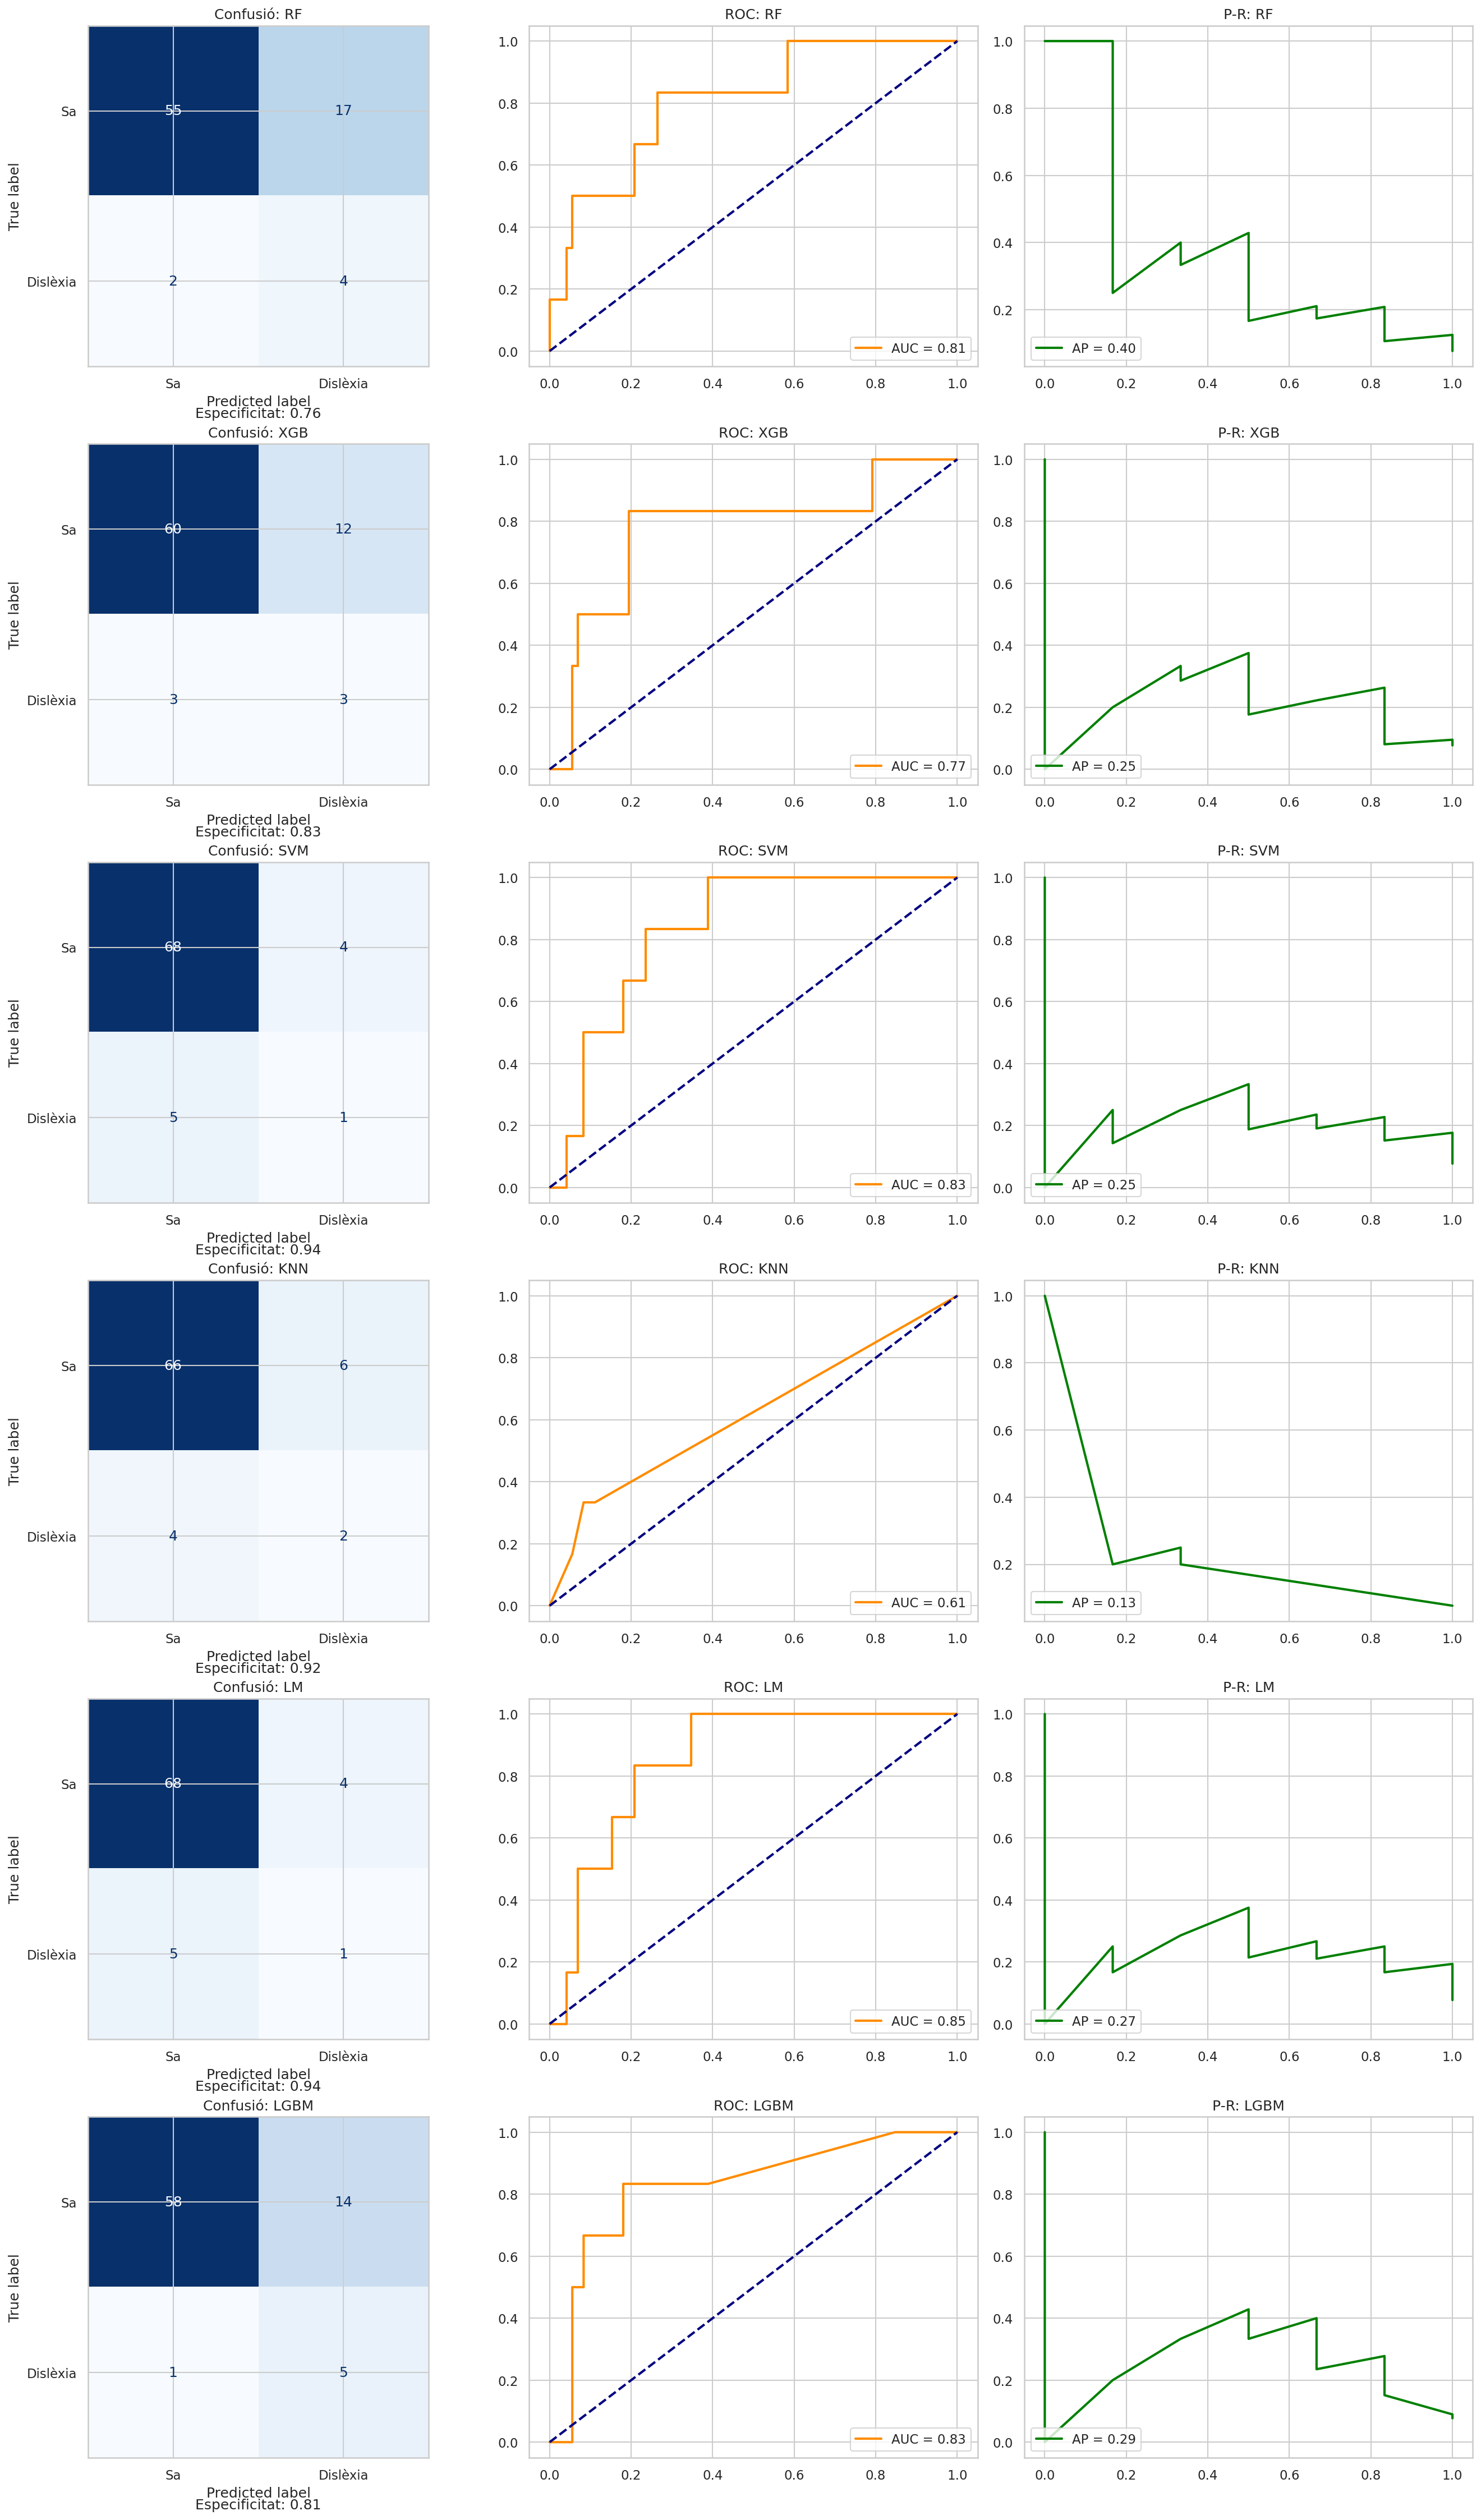

In [ ]:
training.plot_metrics()

##### Entrenament MLP

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def crear_mlp_robusta(input_shape, learning_rate=1e-3):
    model = models.Sequential([
        layers.Input(shape=(input_shape,)),

        layers.Dense(64, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.AUC(curve='PR', name='auc_pr'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

In [ ]:
standard_scaler=StandardScaler()
smote=SMOTENC(categorical_features=categorical_index,random_state=42)

X_train_mlp, X_val_mlp, y_train_mlp,y_val_mlp=train_test_split(
    X_train,y_train, test_size=0.125, stratify=y_train, random_state=42)

X_train_mlp_res=standard_scaler.fit_transform(X_train_mlp)
X_val_mlp_rescaled=standard_scaler.transform(X_val_mlp)
X_test_mlp_rescaled=standard_scaler.transform(X_test)

X_train_mlp_rescaled,y_train_mlp_res=smote.fit_resample(X_train_mlp_res,y_train_mlp)


In [ ]:
configs = [
    {"lr": 1e-3, "batch": 8},
    {"lr": 1e-4, "batch": 8},
    {"lr": 1e-3, "batch": 16},
]

results_mlp = []

In [ ]:
###Escollim millor model

for config in configs:
    print(f"\nConfig: {config}")

    model = crear_mlp_robusta(
        input_shape=X_train_mlp_rescaled.shape[1],
        learning_rate=config["lr"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_pr',
        patience=20,
        mode='max',
        restore_best_weights=True
    )

    history = model.fit(
        X_train_mlp_rescaled,
        y_train_mlp_res,
        validation_data=(X_val_mlp_rescaled, y_val_mlp),
        epochs=200,
        batch_size=config["batch"],
        callbacks=[early_stop],
        verbose=0
    )

    best_val = max(history.history["val_auc_pr"])

    results_mlp.append({
        "config": config,
        "score": best_val,
        "model": model
    })

    print(f"AUC-PR val: {best_val:.4f}")


Config: {'lr': 0.001, 'batch': 8}
AUC-PR val: 0.6146

Config: {'lr': 0.0001, 'batch': 8}
AUC-PR val: 0.4314

Config: {'lr': 0.001, 'batch': 16}
AUC-PR val: 0.4284


In [ ]:
###Reentrenem amb tot el conjunt de train el millor model

best_config=max(results_mlp, key=lambda x: x["score"])["config"]


X_train_mlp_final=X_train_res.copy()
y_train_mlp_final=y_train_res.copy()
X_test_mlp_rescaled=X_test_norm.copy()

model_mlp = crear_mlp_robusta(
        input_shape=X_train_mlp_final.shape[1],
        learning_rate=best_config["lr"]
    )
early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_pr',
        patience=20,
        mode='max',
        restore_best_weights=True
    )
model_mlp.fit(
    X_train_mlp_final,
    y_train_mlp_final,
    epochs=200,
    batch_size=best_config["batch"],
    verbose=0
)



In [ ]:
y_prob_mlp = model_mlp.predict(X_test_mlp_rescaled).ravel()
y_pred_mlp = (y_prob_mlp > 0.5).astype(int)

y_train_prob_mlp=model_mlp.predict(X_train_norm).ravel()
y_train_pred_mlp=(y_train_prob_mlp>0.5).astype(int)

print(f"Classification report test de MLP {classification_report(y_test, y_pred_mlp)}")
print(f"Classification report train de MLP {classification_report(y_train, y_train_pred_mlp)}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Classification report test de MLP               precision    recall  f1-score   support

           0       0.92      0.97      0.95        72
           1       0.00      0.00      0.00         6

    accuracy                           0.90        78
   macro avg       0.46      0.49      0.47        78
weighted avg       0.85      0.90      0.87        78

Classification report train de MLP               precision    recall  f1-score   support

           0       1.00      0.97      0.99       286
           1       0.75      1.00      0.86        24

    accuracy                           0.97       310
   macro avg       0.88      0.99      0.92       310
weighted avg       0.98      0.97      0.98       310



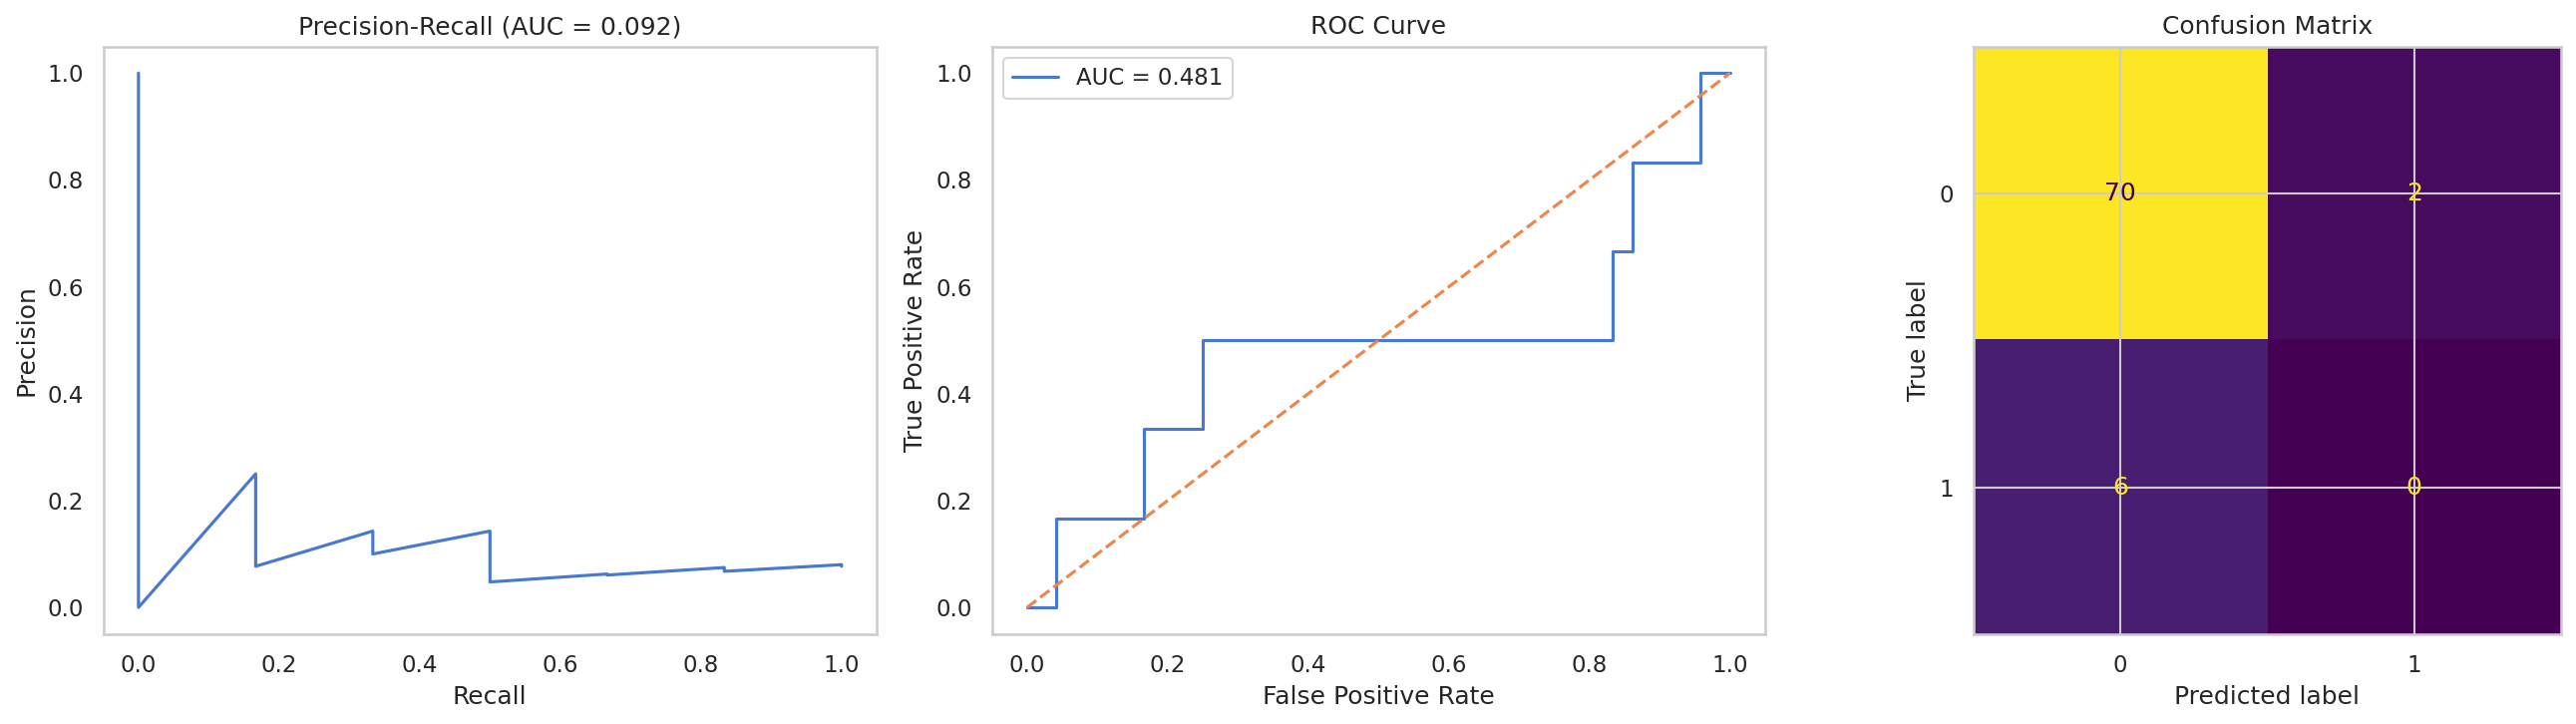

In [ ]:
from sklearn.metrics import (
    precision_recall_curve, auc,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_mlp)
pr_auc = auc(recall, precision)

axes[0].plot(recall, precision)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall (AUC = {pr_auc:.3f})")
axes[0].grid()

# 2. ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob_mlp)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid()

# 3. Confusion Matrix

cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(ax=axes[2], colorbar=False)
axes[2].set_title("Confusion Matrix")


plt.tight_layout()
plt.show()

In [ ]:
with open (storage_path, 'r', encoding='utf-8') as f:
  results=json.load(f)
print(results[166])
print(results[269])

{'arxiu': '/content/drive/MyDrive/TFG/audios_castella_unificats/d_maria9__los_okapis_castellano__llm__castellano_escola_3_4a_0285.m4a', 'duracio': 60.023625, 'lm': 'castella', 'curs': '4', 'dislexia': 1, 'text': 'Los acapis son animales mamíferos que vienen las selvas de África, son casi tan grandes como las girafas y tienen rayas como las cebras. Tienen un ofico fuerte y con su lingo pueden limpiarse hasta las rejas. Se alimentan de las ramas de los árboles y de zanahorias que arrancan de las huertas, de las huertas de las campes de las campes. No soportan temperaturas muy frías ni bien muy fuertes, son muy tímidos y no son fáciles de ver.', 'confianca_mitjana': -0.2897824759435172, 'confianca_std': 0.07441603635777569, 'duracio_parla': 59.0, 'ritme_std': 6.649979114420001, 'silencis': 0.0}


##Second Approach a
#### Training unicament amb embeddings

In [ ]:
from imblearn.over_sampling import SMOTE

columns_no_train=[column for column in df.columns if "emb_" not in column]
X_train2, X_test2, y_train2, y_test2=split(df,columns_no_train)


standard_scaler=StandardScaler()
X_train_norm2=X_train2.copy()
X_test_norm2=X_test2.copy()
X_train_norm2=standard_scaler.fit_transform(X_train2)
X_test_norm2=standard_scaler.transform(X_test2)


#Oversampling
smote=SMOTE(random_state=42)
X_train_res,y_train_res=smote.fit_resample(X_train_norm2,y_train2)

In [ ]:
training_2=Training(X_train2,y_train2,X_test2,y_test2)
results_2=training_2.entrenament(pipeline2, dict_models, scoring,params_grid,cv)

Entrenant rf
Fitting 15 folds for each of 48 candidates, totalling 720 fits
Entrenant xgb
Fitting 15 folds for each of 216 candidates, totalling 3240 fits
Entrenant svm
Fitting 15 folds for each of 32 candidates, totalling 480 fits
Entrenant knn
Fitting 15 folds for each of 20 candidates, totalling 300 fits
Entrenant lm
Fitting 15 folds for each of 20 candidates, totalling 300 fits
Entrenant lgbm
Fitting 15 folds for each of 81 candidates, totalling 1215 fits
[LightGBM] [Info] Number of positive: 286, number of negative: 286
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000269 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5730
[LightGBM] [Info] Number of data points in the train set: 572, number of used features: 30
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

In [ ]:
training_2.print_results()

Model: rf
Best hiperparameters: {'model__class_weight': None, 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best mean F1 in CV: 0.2763290413290413 ± 0.17516098781388587
Best mean Recall in CV: 0.37 ± 0.23366642891095843
Best mean Precision in CV: 0.2269262219262219 ± 0.15077107407253112
Classification report test de rf               precision    recall  f1-score   support

           0       0.98      0.81      0.89        72
           1       0.26      0.83      0.40         6

    accuracy                           0.81        78
   macro avg       0.62      0.82      0.64        78
weighted avg       0.93      0.81      0.85        78

Classification report train de rf               precision    recall  f1-score   support

           0       1.00      0.80      0.89       286
           1       0.30      1.00      0.46        24

    accuracy                           0.82       310
   

(array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1,
        1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0]),
 array([0.31878136, 0.06316813, 0.0389686 , 0.12036632, 0.27842667,
        0.07194798, 0.03747586, 0.04861111, 0.05118389, 0.05741155,
        0.04861111, 0.05170624, 0.0838577 , 0.05807379, 0.06764935,
        0.0716244 , 0.14766652, 0.15231073, 0.04884779, 0.04501797,
        0.06297156, 0.20915469, 0.26453971, 0.5436722 , 0.0387052 ,
        0.2485869 , 0.04153072, 0.07709635, 0.20660863, 0.38397091,
        0.03578641, 0.56364626, 0.05261149, 0.06131021, 0.63457642,
        0.03626628, 0.06271084, 0.34459374, 0.04857851, 0.09401787,
        0.05797156, 0.6737104 , 0.71930426, 0.22071654, 0.11983845,
        0.05671157, 0.05118389, 0.03645432, 0.69038772, 0.0701306 ,
        0.03616698, 0.04270045, 0.03916302, 0.038894

In [ ]:
training_2.print_results_profund()

ANALITZANT MODEL: RF amb threshold: 0.32

 RECALL: Detectats 5 de 6 nens amb dislexia.

 PRECISSION: 5 dislexics eren reals dels 19 predits.

Detalle de los niños con dislexia:
     Realidad  Prediccion  Prob_Dislexia  Error
31          1           1       0.693825  False
269         1           1       0.338002  False
340         1           1       0.426075  False
166         1           0       0.115010   True
130         1           1       0.325635  False
157         1           1       0.475860  False
     Realidad  Prediccion  Prob_Dislexia  Error
355         0           1       0.327762   True
6           0           1       0.591613   True
31          1           1       0.693825  False
269         1           1       0.338002  False
300         0           1       0.650517   True
387         0           1       0.650507   True
158         0           1       0.457175   True
114         0           1       0.391780   True
340         1           1       0.426075  False
377    

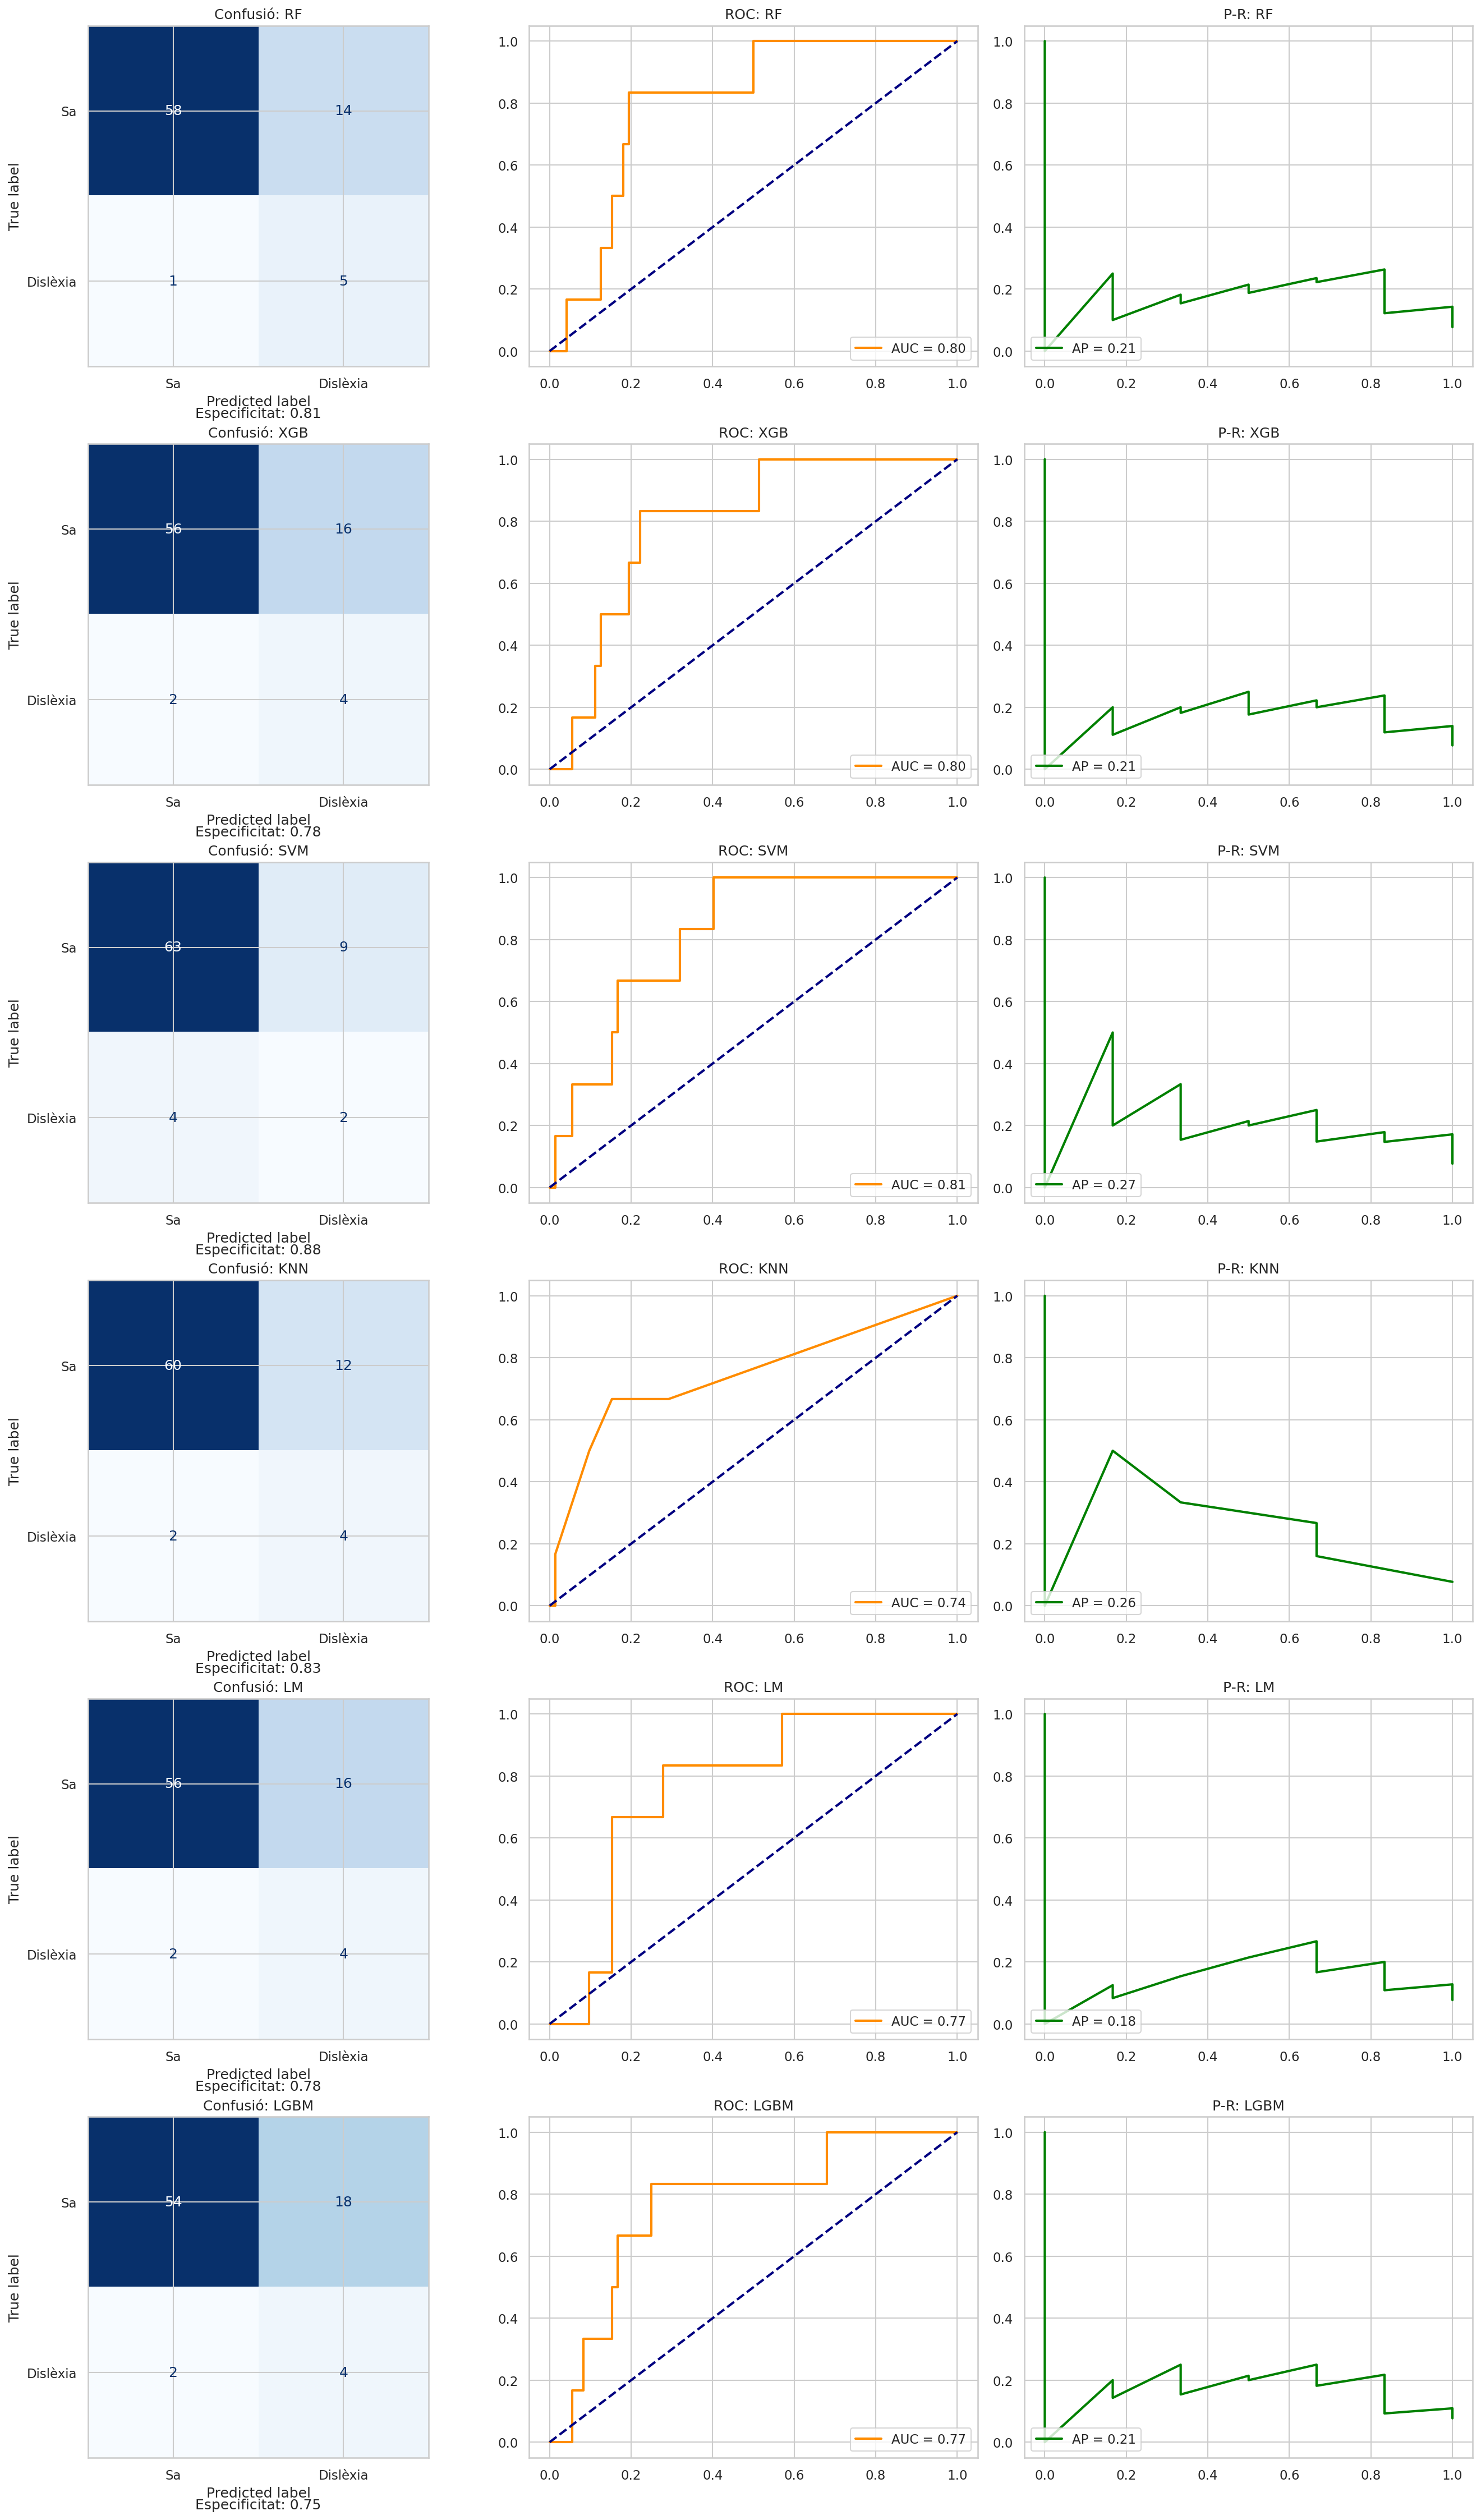

In [ ]:
training_2.plot_metrics()

##Second Approach b
#### Training unicament amb embeddings i enregistraments

In [ ]:
def is_silent(chunk, threshold=0.01):
    return np.mean(np.abs(chunk)) < threshold

In [ ]:
SR = 16000
CHUNK = 2 * SR #fragments de 2 segons

def chunk_audio(audio):
    chunks = []
    for i in range(0, len(audio), CHUNK):
        frag = audio[i:i+CHUNK]
        if len(frag) < 0.25 * CHUNK:
          continue
        chunks.append(frag)

    return chunks

In [ ]:
def get_embedding(model, audio_chunk):
    audio_chunk = whisper.pad_or_trim(audio_chunk)

    mel = whisper.log_mel_spectrogram(audio_chunk).to(model.device).unsqueeze(0)

    with torch.no_grad():
        emb = model.encoder(mel)

    emb = emb.squeeze(0).cpu().numpy()
    mean=emb.mean(axis=0)
    std=emb.std(axis=0)

    res=np.concatenate([mean,std])

    # 1024 dim
    return res

In [ ]:
with open(storage_path, 'r', encoding='utf-8') as f:
  results=json.load(f)

df_2=[]
model=whisper.load_model("base")
for result in results:
  arxiu=result["arxiu"]
  audio=whisper.load_audio(arxiu)
  chunks=chunk_audio(audio)
  for i,chunk in enumerate(chunks):
    if is_silent(chunk):
      continue
    emb=get_embedding(model,chunk)
    df_2.append({
    "arxiu":arxiu,
    "emb":emb.tolist(),
    "label":result["dislexia"],
    "curs":result["curs"],
    "id_audio":i})

df_2=pd.DataFrame(df_2)
emb_df=pd.DataFrame(df_2["emb"].tolist(), index=df_2.index)
emb_df.columns=[f"emb_{i}" for i in range (emb_df.shape[1])]
df=pd.concat([df_2,emb_df], axis=1)
df=df.drop(columns=["emb"])

df.to_json(storage_path_3, orient="records", force_ascii=False, indent=4) ###Rectificat, abans s'havia fet json.dump(df) i no es soportava, d'aquesta manera es guarda com a json

In [ ]:
#DataFrame
print(df)

                                                 arxiu  confianca_mitjana  \
0    /content/drive/MyDrive/TFG/audios_castella_uni...          -0.708783   
1    /content/drive/MyDrive/TFG/audios_castella_uni...          -0.399684   
2    /content/drive/MyDrive/TFG/audios_castella_uni...          -0.260362   
3    /content/drive/MyDrive/TFG/audios_castella_uni...          -0.243936   
4    /content/drive/MyDrive/TFG/audios_castella_uni...          -0.207233   
..                                                 ...                ...   
383  /content/drive/MyDrive/TFG/audios_castella_uni...          -1.493262   
384  /content/drive/MyDrive/TFG/audios_castella_uni...          -1.422524   
385  /content/drive/MyDrive/TFG/audios_castella_uni...          -0.569436   
386  /content/drive/MyDrive/TFG/audios_castella_uni...          -1.382388   
387  /content/drive/MyDrive/TFG/audios_castella_uni...          -3.751258   

     confianca_std  ritme_std  silencis       cer       wer  velocitat  \
0

#####DataFrame2

In [24]:
with open(storage_path_3, 'r', encoding='utf-8') as f:
  results_2=json.load(f)
df_2=pd.DataFrame(results_2)
df_2.head(30)

,arxiu,label,curs,id_audio,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,...,emb_1014,emb_1015,emb_1016,emb_1017,emb_1018,emb_1019,emb_1020,emb_1021,emb_1022,emb_1023
0,/content/drive/MyDrive/TFG/audios_castella_uni...,0,2,0,-0.205522,-0.917753,0.245795,-1.209103,0.176003,1.553939,...,0.389247,0.336946,0.536093,0.637417,0.554288,0.788321,0.370925,0.568239,0.628039,0.312192
1,/content/drive/MyDrive/TFG/audios_castella_uni...,0,2,1,-0.131226,-0.650348,0.185882,-1.251219,0.070716,1.577932,...,0.389501,0.320373,0.545978,0.595032,0.643711,0.776326,0.339164,0.610677,0.616228,0.279387
2,/content/drive/MyDrive/TFG/audios_castella_uni...,0,2,2,-0.204333,-0.833798,0.299303,-1.195191,0.179827,1.671123,...,0.413619,0.361459,0.495523,0.667549,0.506880,0.768401,0.363387,0.606492,0.663920,0.374961
3,/content/drive/MyDrive/TFG/audios_castella_uni...,0,2,3,-0.331029,-0.979132,0.143137,-1.306986,0.028022,1.591153,...,0.362093,0.368336,0.502342,0.812981,0.599229,0.766327,0.371014,0.597071,0.646460,0.314343
4,/content/drive/MyDrive/TFG/audios_castella_uni...,0,2,4,-0.222699,-0.795985,0.173358,-1.214523,0.173298,1.664241,...,0.371482,0.314491,0.528367,0.631718,0.667549,0.773157,0.430216,0.613274,0.583616,0.302194
5,/content/drive/MyDrive/TFG/audios_castella_uni...,0,2,5,0.087892,-0.542417,0.234203,-1.084810,0.218395,1.542401,...,0.366820,0.313651,0.505962,0.555088,0.596832,0.732099,0.330442,0.552042,0.496874,0.305716
6,/content/drive/MyDrive/TFG/audios_castella_uni...,0,2,6,-0.232224,-0.795477,0.163366,-1.282593,0.117414,1.724361,...,0.358554,0.346744,0.500836,0.580604,0.632806,0.747418,0.358653,0.567767,0.597722,0.335384
7,/content/drive/MyDrive/TFG/audios_castella_uni...,0,2,7,-0.269359,-0.854616,0.184433,-1.242818,0.126417,1.574157,...,0.359699,0.326069,0.502598,0.595081,0.587952,0.745825,0.377306,0.564040,0.642061,0.331035
8,/content/drive/MyDrive/TFG/audios_castella_uni...,0,2,8,-0.200829,-0.785893,0.206124,-1.126200,0.075570,1.528667,...,0.375423,0.290749,0.479784,0.515035,0.693213,0.762876,0.392583,0.643274,0.634528,0.321243
9,/content/drive/MyDrive/TFG/audios_castella_uni...,0,2,9,-0.359764,-0.863336,0.269556,-1.224836,0.138816,1.614412,...,0.411429,0.313226,0.527220,0.588439,0.616227,0.814195,0.398712,0.646845,0.686012,0.297413


In [25]:
df_dislexia=df_2[df_2["label"]==1]
print(f"Infants amb dislexia: {len(df_dislexia.groupby("arxiu"))}")
print(f"Fragments amb dislexia: {len(df_dislexia)}")

Infants amb dislexia: 30
Fragments amb dislexia: 1712


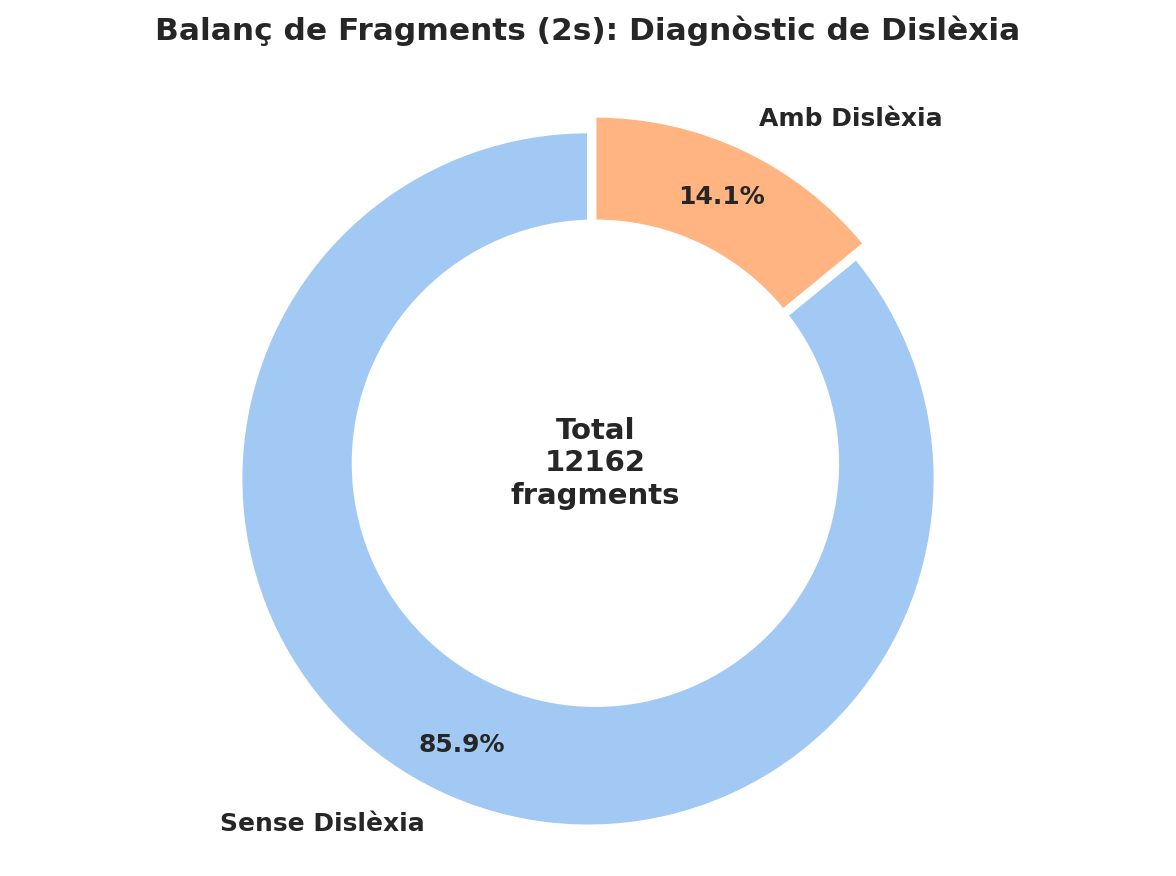

In [26]:
def plot_balance_chunks(df):
    counts = df['label'].value_counts()
    labels = ['Sense Dislèxia', 'Amb Dislèxia']
    colors = sns.color_palette('pastel')[0:2]

    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        pctdistance=0.85,
        explode=[0.05, 0],
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )

    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    total = len(df)

    plt.text(
        0, 0,
        f'Total\n{total}\nfragments',
        ha='center',
        va='center',
        fontsize=14,
        fontweight='bold'
    )

    plt.title(
        'Balanç de Fragments (2s): Diagnòstic de Dislèxia',
        fontsize=15,
        pad=20,
        fontweight='bold'
    )

    plt.axis('equal')
    plt.tight_layout()
    plt.show()

plot_balance_chunks(df_2)

In [27]:
df_2["stratification"]=df_2["curs"].astype(str)+"_"+df_2["label"].astype(str)
groups=df_2["arxiu"]

sfdk=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sfdk.split(df_2, df_2["stratification"], groups=groups))
train_df = df_2.iloc[train_idx]
test_df = df_2.iloc[test_idx]

y_train_emb=train_df["label"]
y_test_emb=test_df["label"]

X_train_emb=train_df[[column for column in train_df.columns if "emb_" in column]]
X_test_emb=test_df[[column for column in test_df.columns if "emb_" in column]]
groups_train=train_df["arxiu"]

In [27]:
training_3 = Training(X_train_emb, y_train_emb, X_test_emb, y_test_emb, groups_train)

results_3 = training_3.entrenament(
    pipeline3,
    {"rf":dict_models["rf"]},
    #{"xgb": dict_models["xgb"]},
    #{"svm": dict_models["svm"]},
    #{"knn": dict_models["knn"]},
    #{"lm": dict_models["lm"]},
    #{"lgbm": dict_models["lgbm"]},
    scoring,
    params_grid,
    cv_groups
)
joblib.dump(results_3["rf"], storage_rf)
#joblib.dump(results_3["xgb"], storage_xgb)
#joblib.dump(results_3["svm"],storage_svm)
#joblib.dump(results_3["knn"],storage_knn)
#joblib.dump(results_3["lm"],storage_lm)
#joblib.dump(results_3["lgbm"],storage_lgbm)


Entrenant rf
Fitting 5 folds for each of 48 candidates, totalling 240 fits


['/content/drive/MyDrive/modelo_rf.pkl']

In [28]:
training_3.print_results()

Model: rf
Best hiperparameters: {'model__class_weight': None, 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best mean F1 in CV: 0.3357256478276651 ± 0.09839230484242113
Best mean Recall in CV: 0.7019616812942742 ± 0.023336416852788214
Best mean Precision in CV: 0.2272425032760252 ± 0.08190492924771132
Classification report test de rf               precision    recall  f1-score   support

           0       0.94      0.50      0.65      2055
           1       0.28      0.87      0.43       472

    accuracy                           0.57      2527
   macro avg       0.61      0.68      0.54      2527
weighted avg       0.82      0.57      0.61      2527

Classification report train de rf               precision    recall  f1-score   support

           0       0.99      0.52      0.68      8395
           1       0.23      0.95      0.37      1240

    accuracy                           0.5

(array([0, 1, 1, ..., 1, 1, 1]),
 array([0.34695357, 0.46298759, 0.41105086, ..., 0.66394062, 0.5654025 ,
        0.54481822]))

In [29]:
training_3.print_results_profund()

ANALITZANT MODEL: RF amb threshold: 0.39

 RECALL: Detectats 409 de 472 nens amb dislexia.

 PRECISSION: 409 dislexics eren reals dels 1444 predits.

Detalle de los niños con dislexia:
       Realidad  Prediccion  Prob_Dislexia  Error
2825          1           1       0.578944  False
2826          1           0       0.305042   True
2827          1           0       0.235542   True
2828          1           0       0.360719   True
2829          1           1       0.517053  False
...         ...         ...            ...    ...
12015         1           1       0.630407  False
12016         1           0       0.362017   True
12017         1           1       0.663941  False
12018         1           1       0.565402  False
12019         1           1       0.544818  False

[472 rows x 4 columns]
       Realidad  Prediccion  Prob_Dislexia  Error
173           0           1       0.462988   True
174           0           1       0.411051   True
175           0           1       0.59240

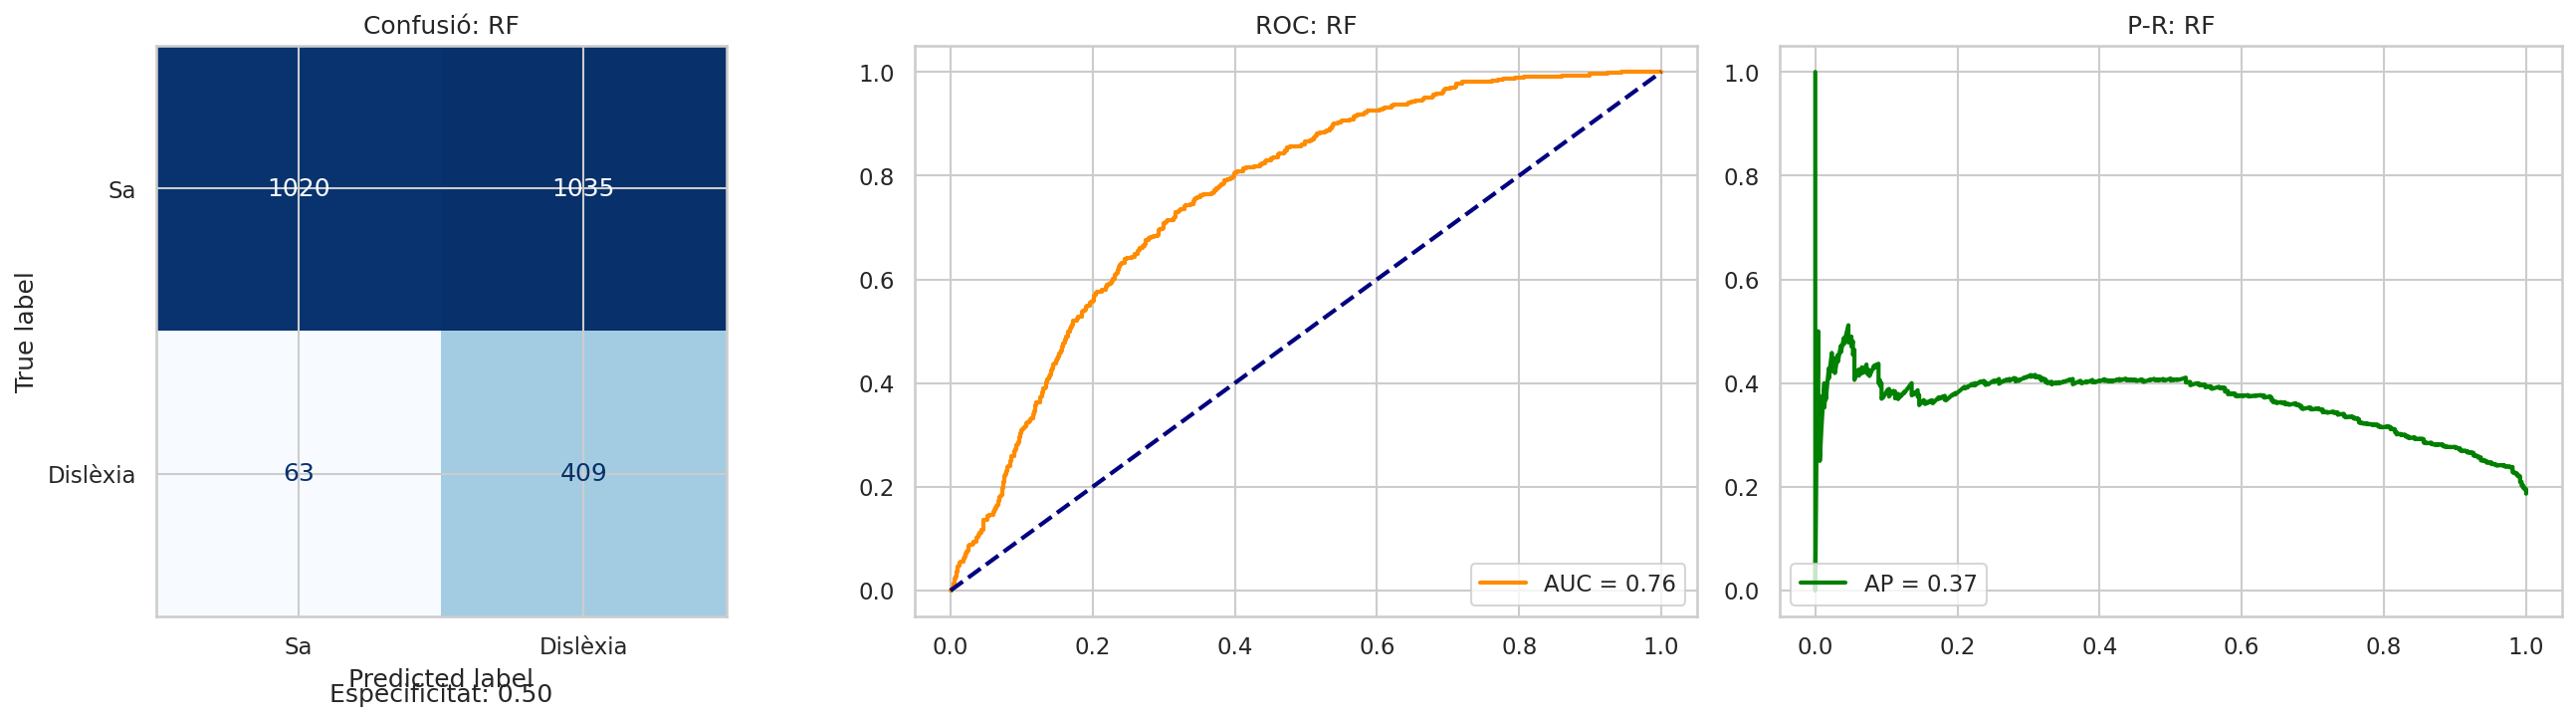

In [30]:
training_3.plot_metrics()

In [28]:
training_3 = Training(X_train_emb, y_train_emb, X_test_emb, y_test_emb, groups_train)
training_3.results["rf"]=joblib.load(storage_rf)
#training_3.results["xgb"]=joblib.load(storage_xgb)
#training_3.results["svm"]=joblib.load(storage_svm)
#training_3.results["knn"]=joblib.load(storage_knn)
#training_3.results["lm"]=joblib.load(storage_lm)
#training_3.results["lgbm"]=joblib.load(storage_lgbm)

In [29]:
y_pred_emb, y_test_emb_probs=training_3.print_results()

Model: rf
Best hiperparameters: {'model__class_weight': None, 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best mean F1 in CV: 0.3357256478276651 ± 0.09839230484242113
Best mean Recall in CV: 0.7019616812942742 ± 0.023336416852788214
Best mean Precision in CV: 0.2272425032760252 ± 0.08190492924771132
Classification report test de rf               precision    recall  f1-score   support

           0       0.94      0.50      0.65      2055
           1       0.28      0.87      0.43       472

    accuracy                           0.57      2527
   macro avg       0.61      0.68      0.54      2527
weighted avg       0.82      0.57      0.61      2527

Classification report train de rf               precision    recall  f1-score   support

           0       0.99      0.52      0.68      8395
           1       0.23      0.95      0.37      1240

    accuracy                           0.5

In [30]:
training_3.print_results_profund()

ANALITZANT MODEL: RF amb threshold: 0.39

 RECALL: Detectats 409 de 472 nens amb dislexia.

 PRECISSION: 409 dislexics eren reals dels 1444 predits.

Detalle de los niños con dislexia:
       Realidad  Prediccion  Prob_Dislexia  Error
2825          1           1       0.578944  False
2826          1           0       0.305042   True
2827          1           0       0.235542   True
2828          1           0       0.360719   True
2829          1           1       0.517053  False
...         ...         ...            ...    ...
12015         1           1       0.630407  False
12016         1           0       0.362017   True
12017         1           1       0.663941  False
12018         1           1       0.565402  False
12019         1           1       0.544818  False

[472 rows x 4 columns]
       Realidad  Prediccion  Prob_Dislexia  Error
173           0           1       0.462988   True
174           0           1       0.411051   True
175           0           1       0.59240

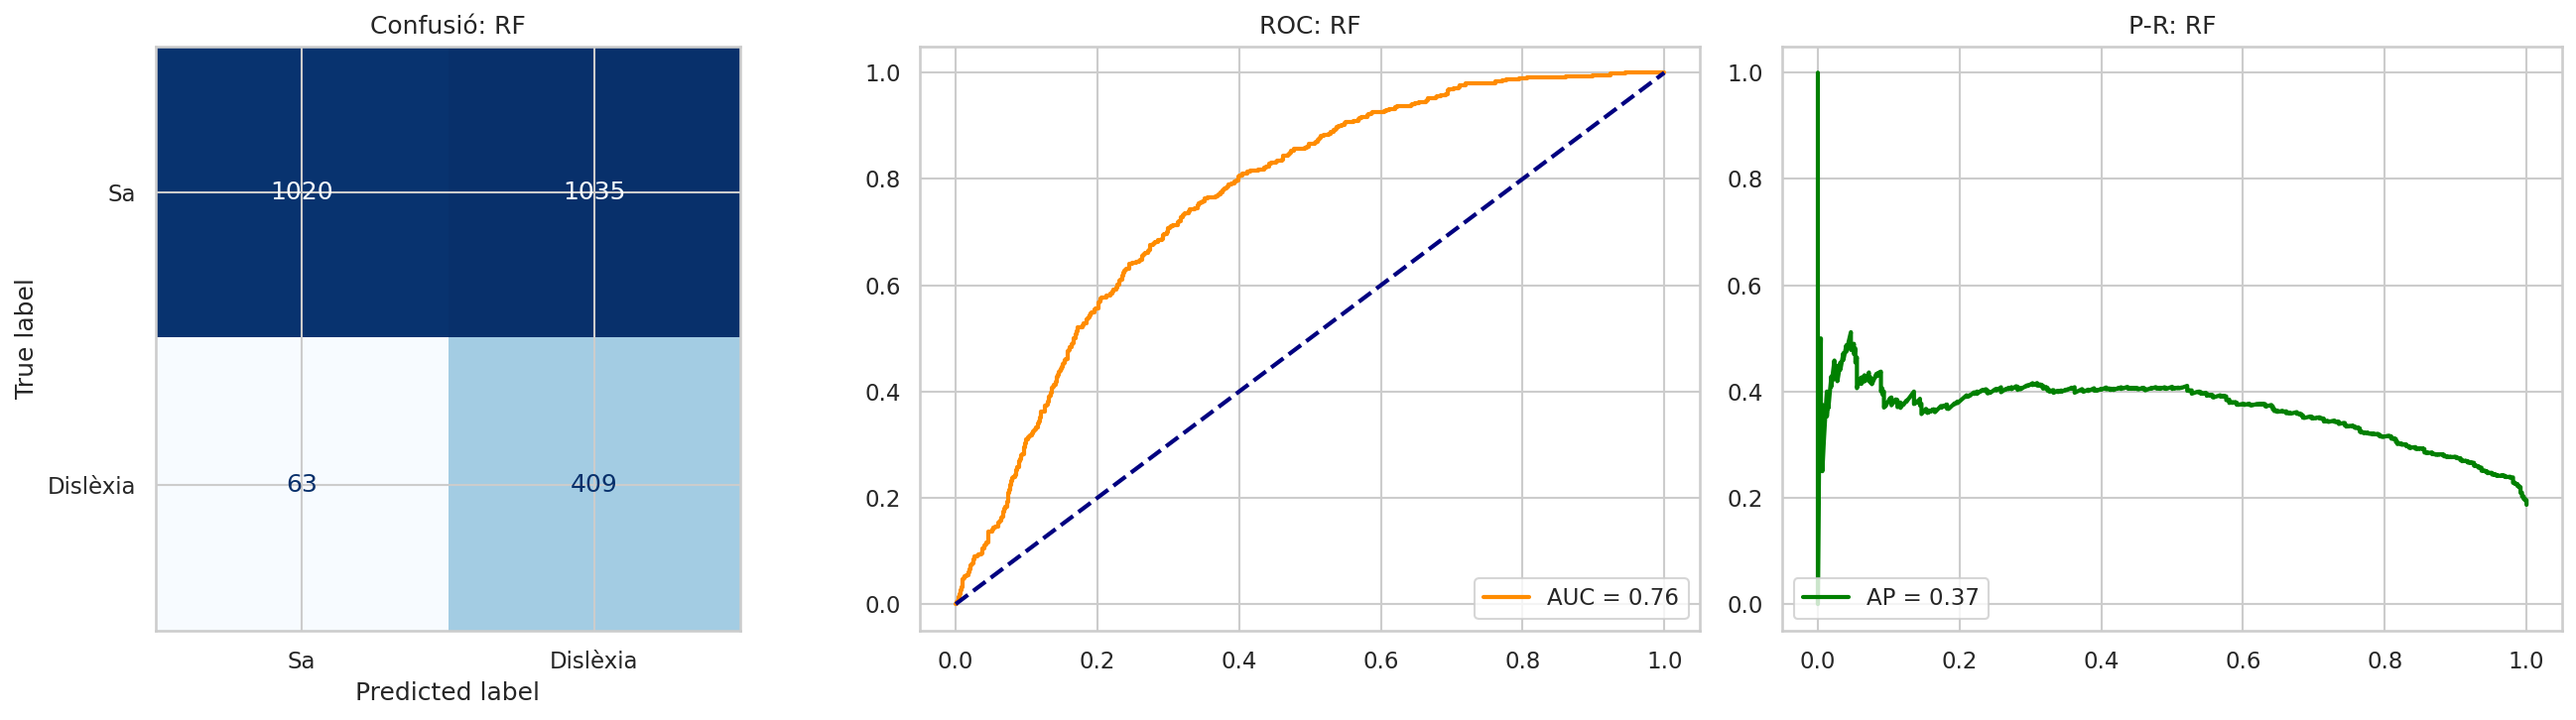

In [31]:
training_3.plot_metrics()

#### Avaluació per nen

In [32]:
df_pred=df_2.loc[X_test_emb.index]
df_pred["pred"]=y_pred_emb
df_pred["test"]=y_test_emb
df_pred["probs"]=y_test_emb_probs
# Votación mayoritaria por audio
y_pred_audio = (
    df_pred
    .groupby("arxiu")["pred"]
    .agg(lambda x: x.value_counts().idxmax())
)
y_test_audio = (
    df_pred
    .groupby("arxiu")["test"]
    .agg(lambda x: x.value_counts().idxmax())
)
y_probs_audio = (
    df_pred
    .groupby("arxiu")["probs"]
    .mean()
)

y_pred_audio_default = y_pred_audio.sort_index()
y_test_audio = y_test_audio.sort_index()
y_probs_audio = y_probs_audio.sort_index()
y_pred_audio = (y_probs_audio >= 0.51).astype(int)

print(sum(x for x in y_pred_audio if x==1))
print(classification_report(y_test_audio, y_pred_audio))

16
              precision    recall  f1-score   support

           0       0.98      0.87      0.92        67
           1       0.44      0.88      0.58         8

    accuracy                           0.87        75
   macro avg       0.71      0.87      0.75        75
weighted avg       0.92      0.87      0.88        75



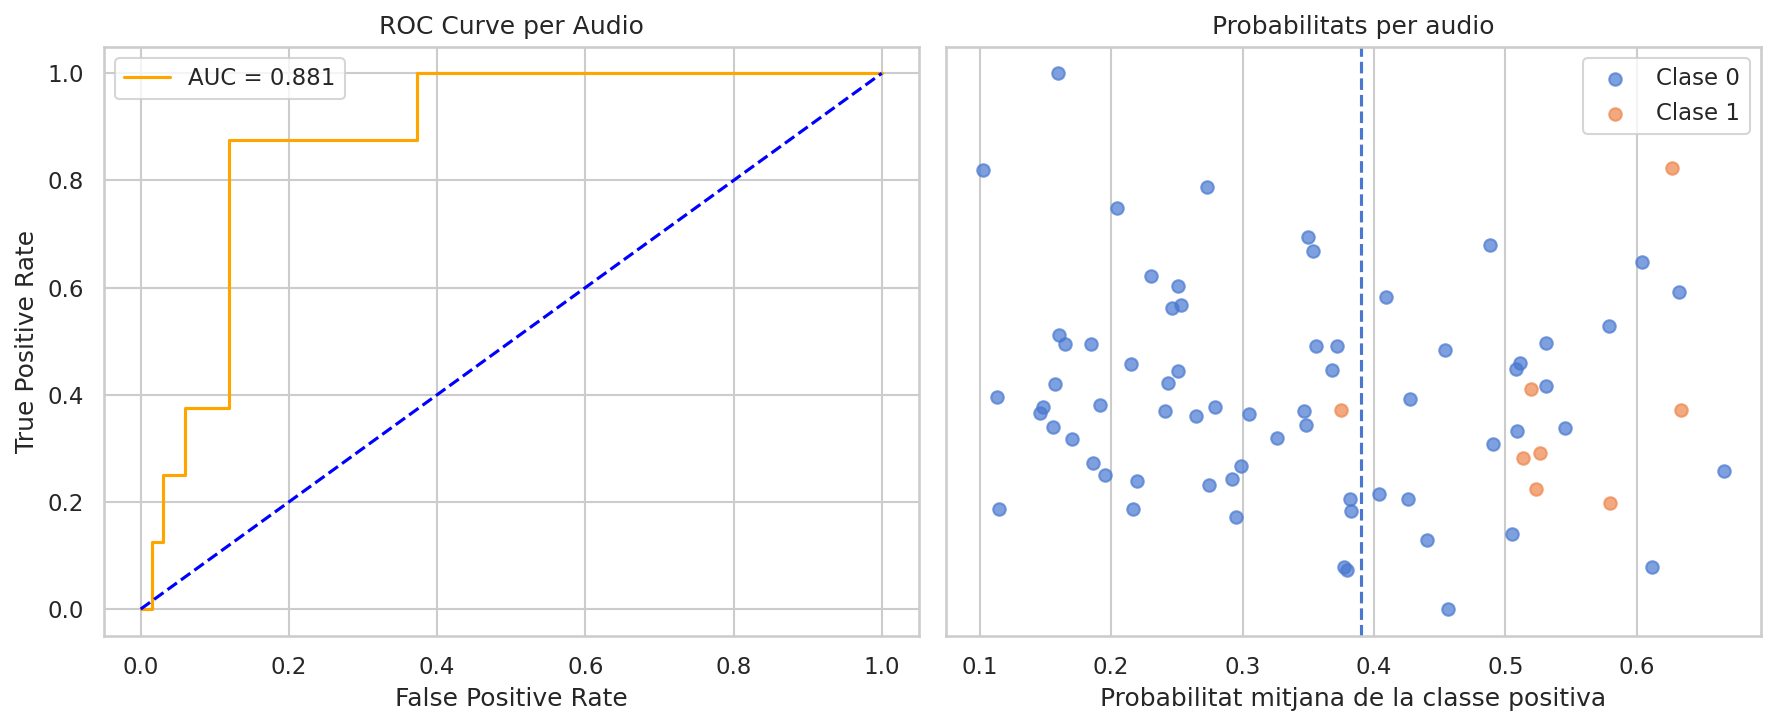

In [34]:
# ROC
fpr, tpr, thresholds = roc_curve(y_test_audio, y_probs_audio)
roc_auc = auc(fpr, tpr)

# Datos scatter
y_jitter = np.random.normal(0, 0.02, size=len(y_probs_audio))

probs = y_probs_audio.values
labels = y_test_audio.values

# Figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# =========================
# ROC Curve
# =========================
axes[0].plot(fpr, tpr, color='orange', label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="blue")

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve per Audio")
axes[0].legend()

# =========================
# Scatter probabilidades
# =========================

# Clase 0
axes[1].scatter(
    probs[labels == 0],
    y_jitter[labels == 0],
    alpha=0.7,
    label="Clase 0"
)

# Clase 1
axes[1].scatter(
    probs[labels == 1],
    y_jitter[labels == 1],
    alpha=0.7,
    label="Clase 1"
)

axes[1].axvline(0.39, linestyle="--")

axes[1].set_xlabel("Probabilitat mitjana de la classe positiva")
axes[1].set_yticks([])

axes[1].set_title("Probabilitats per audio")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
print(df_2)

                                                   arxiu  label curs  \
0      /content/drive/MyDrive/TFG/audios_castella_uni...      0    2   
1      /content/drive/MyDrive/TFG/audios_castella_uni...      0    2   
2      /content/drive/MyDrive/TFG/audios_castella_uni...      0    2   
3      /content/drive/MyDrive/TFG/audios_castella_uni...      0    2   
4      /content/drive/MyDrive/TFG/audios_castella_uni...      0    2   
...                                                  ...    ...  ...   
12157  /content/drive/MyDrive/TFG/audios_castella_uni...      0    3   
12158  /content/drive/MyDrive/TFG/audios_castella_uni...      0    3   
12159  /content/drive/MyDrive/TFG/audios_castella_uni...      0    3   
12160  /content/drive/MyDrive/TFG/audios_castella_uni...      0    3   
12161  /content/drive/MyDrive/TFG/audios_castella_uni...      0    3   

       id_audio     emb_0     emb_1     emb_2     emb_3     emb_4     emb_5  \
0             0 -0.205522 -0.917753  0.245795 -1.209103 

## APPROACH 3

In [ ]:
print(df.head(20))

                                                arxiu  confianca_mitjana  \
0   /content/drive/MyDrive/TFG/audios_castella_uni...          -0.708783   
1   /content/drive/MyDrive/TFG/audios_castella_uni...          -0.399684   
2   /content/drive/MyDrive/TFG/audios_castella_uni...          -0.260362   
3   /content/drive/MyDrive/TFG/audios_castella_uni...          -0.243936   
4   /content/drive/MyDrive/TFG/audios_castella_uni...          -0.207233   
5   /content/drive/MyDrive/TFG/audios_castella_uni...          -0.226146   
6   /content/drive/MyDrive/TFG/audios_castella_uni...          -0.550943   
7   /content/drive/MyDrive/TFG/audios_castella_uni...          -0.450558   
8   /content/drive/MyDrive/TFG/audios_castella_uni...          -0.375613   
9   /content/drive/MyDrive/TFG/audios_castella_uni...          -0.243850   
10  /content/drive/MyDrive/TFG/audios_castella_uni...          -0.364839   
11  /content/drive/MyDrive/TFG/audios_castella_uni...          -0.397852   
12  /content

In [ ]:
columns_no_train=["arxiu","dislexia","stratification"]
X_train,X_test,y_train,y_test=split(df,columns_no_train)

In [ ]:
pca_cols=[col for col in df.columns if "emb" in col]

scale_cols= ["confianca_mitjana", "confianca_std", "ritme_std", "silencis",
    "cer", "wer", "velocitat", "ratio"]

In [ ]:
preprocessor5 = ColumnTransformer(
    transformers=[
        ("pca_block", Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=30, random_state=42))
        ]), pca_cols),

        ("scaler_only", StandardScaler(), scale_cols)
    ],
    remainder="passthrough"
)

pipeline5 = Pipeline([
    ("smote", SMOTENC(
        categorical_features=categorical_index,
        random_state=42
    )),
    ("prep", preprocessor5),
    ("model", rf)
])

In [ ]:
training_5 = Training(X_train,y_train,X_test,y_test)
training_5.entrenament(pipeline5, dict_models, scoring,params_grid,cv)

Entrenant rf
Fitting 15 folds for each of 48 candidates, totalling 720 fits
Entrenant xgb
Fitting 15 folds for each of 216 candidates, totalling 3240 fits
Entrenant svm
Fitting 15 folds for each of 32 candidates, totalling 480 fits
Entrenant knn
Fitting 15 folds for each of 20 candidates, totalling 300 fits
Entrenant lm
Fitting 15 folds for each of 20 candidates, totalling 300 fits
Entrenant lgbm
Fitting 15 folds for each of 81 candidates, totalling 1215 fits
[LightGBM] [Info] Number of positive: 286, number of negative: 286
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000450 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7098
[LightGBM] [Info] Number of data points in the train set: 572, number of used features: 40


{'rf': {'model': Pipeline(steps=[('smote', SMOTENC(categorical_features=[9], random_state=42)),
                  ('prep',
                   ColumnTransformer(remainder='passthrough',
                                     transformers=[('pca_block',
                                                    Pipeline(steps=[('scaler',
                                                                     StandardScaler()),
                                                                    ('pca',
                                                                     PCA(n_components=30,
                                                                         random_state=42))]),
                                                    ['emb_0', 'emb_1', 'emb_2',
                                                     'emb_3', 'emb_4', 'emb_5',
                                                     'emb_6', 'emb_7', 'emb_8',
                                                     'emb_9', 'emb_10', 'emb_11',
 

In [ ]:
training_5.print_results()

Model: rf
Best hiperparameters: {'model__class_weight': None, 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best mean F1 in CV: 0.3412766862766862 ± 0.18410002733473477
Best mean Recall in CV: 0.48000000000000004 ± 0.27856776554368246
Best mean Precision in CV: 0.2723293373293373 ± 0.15168553163962165
Classification report test de rf               precision    recall  f1-score   support

           0       0.97      0.78      0.86        72
           1       0.20      0.67      0.31         6

    accuracy                           0.77        78
   macro avg       0.58      0.72      0.58        78
weighted avg       0.91      0.77      0.82        78

Classification report train de rf               precision    recall  f1-score   support

           0       1.00      0.83      0.91       286
           1       0.33      1.00      0.50        24

    accuracy                           0.8

(array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
        0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0]),
 array([1.40307551e-04, 2.10169301e-04, 3.45321089e-04, 7.29441325e-05,
        4.19334552e-01, 3.07981459e-04, 1.27488815e-04, 1.73317400e-04,
        7.53892576e-05, 1.72554935e-04, 2.17144669e-04, 7.51961223e-04,
        2.16690177e-04, 2.52090672e-03, 9.27957373e-04, 1.48275280e-04,
        2.51641677e-04, 2.89762166e-01, 8.67165166e-04, 6.86780806e-05,
        1.25985568e-03, 3.42309725e-03, 3.57118912e-02, 1.09280983e-01,
        3.34008956e-04, 3.17933647e-03, 3.37423490e-04, 1.83651099e-03,
        8.03601304e-04, 2.07475199e-01, 2.17932604e-04, 1.88483924e-02,
        7.45877267e-04, 1.41549925e-04, 1.18331213e-01, 2.01193136e-04,
        9.87940620e-04, 6.60218654e-03, 7.87531117e-05, 8.74145365e-04,
        9.81

In [ ]:
training_5.print_results_profund()

ANALITZANT MODEL: RF amb threshold: 0.31

 RECALL: Detectats 4 de 6 nens amb dislexia.

 PRECISSION: 4 dislexics eren reals dels 20 predits.

Detalle de los niños con dislexia:
     Realidad  Prediccion  Prob_Dislexia  Error
31          1           1       0.720689  False
269         1           0       0.247141   True
340         1           1       0.487075  False
166         1           0       0.026353   True
130         1           1       0.403367  False
157         1           1       0.551824  False
     Realidad  Prediccion  Prob_Dislexia  Error
355         0           1       0.551016   True
299         0           1       0.606859   True
225         0           1       0.392083   True
120         0           1       0.400399   True
267         0           1       0.559043   True
6           0           1       0.417549   True
31          1           1       0.720689  False
300         0           1       0.491881   True
387         0           1       0.626661   True
158    

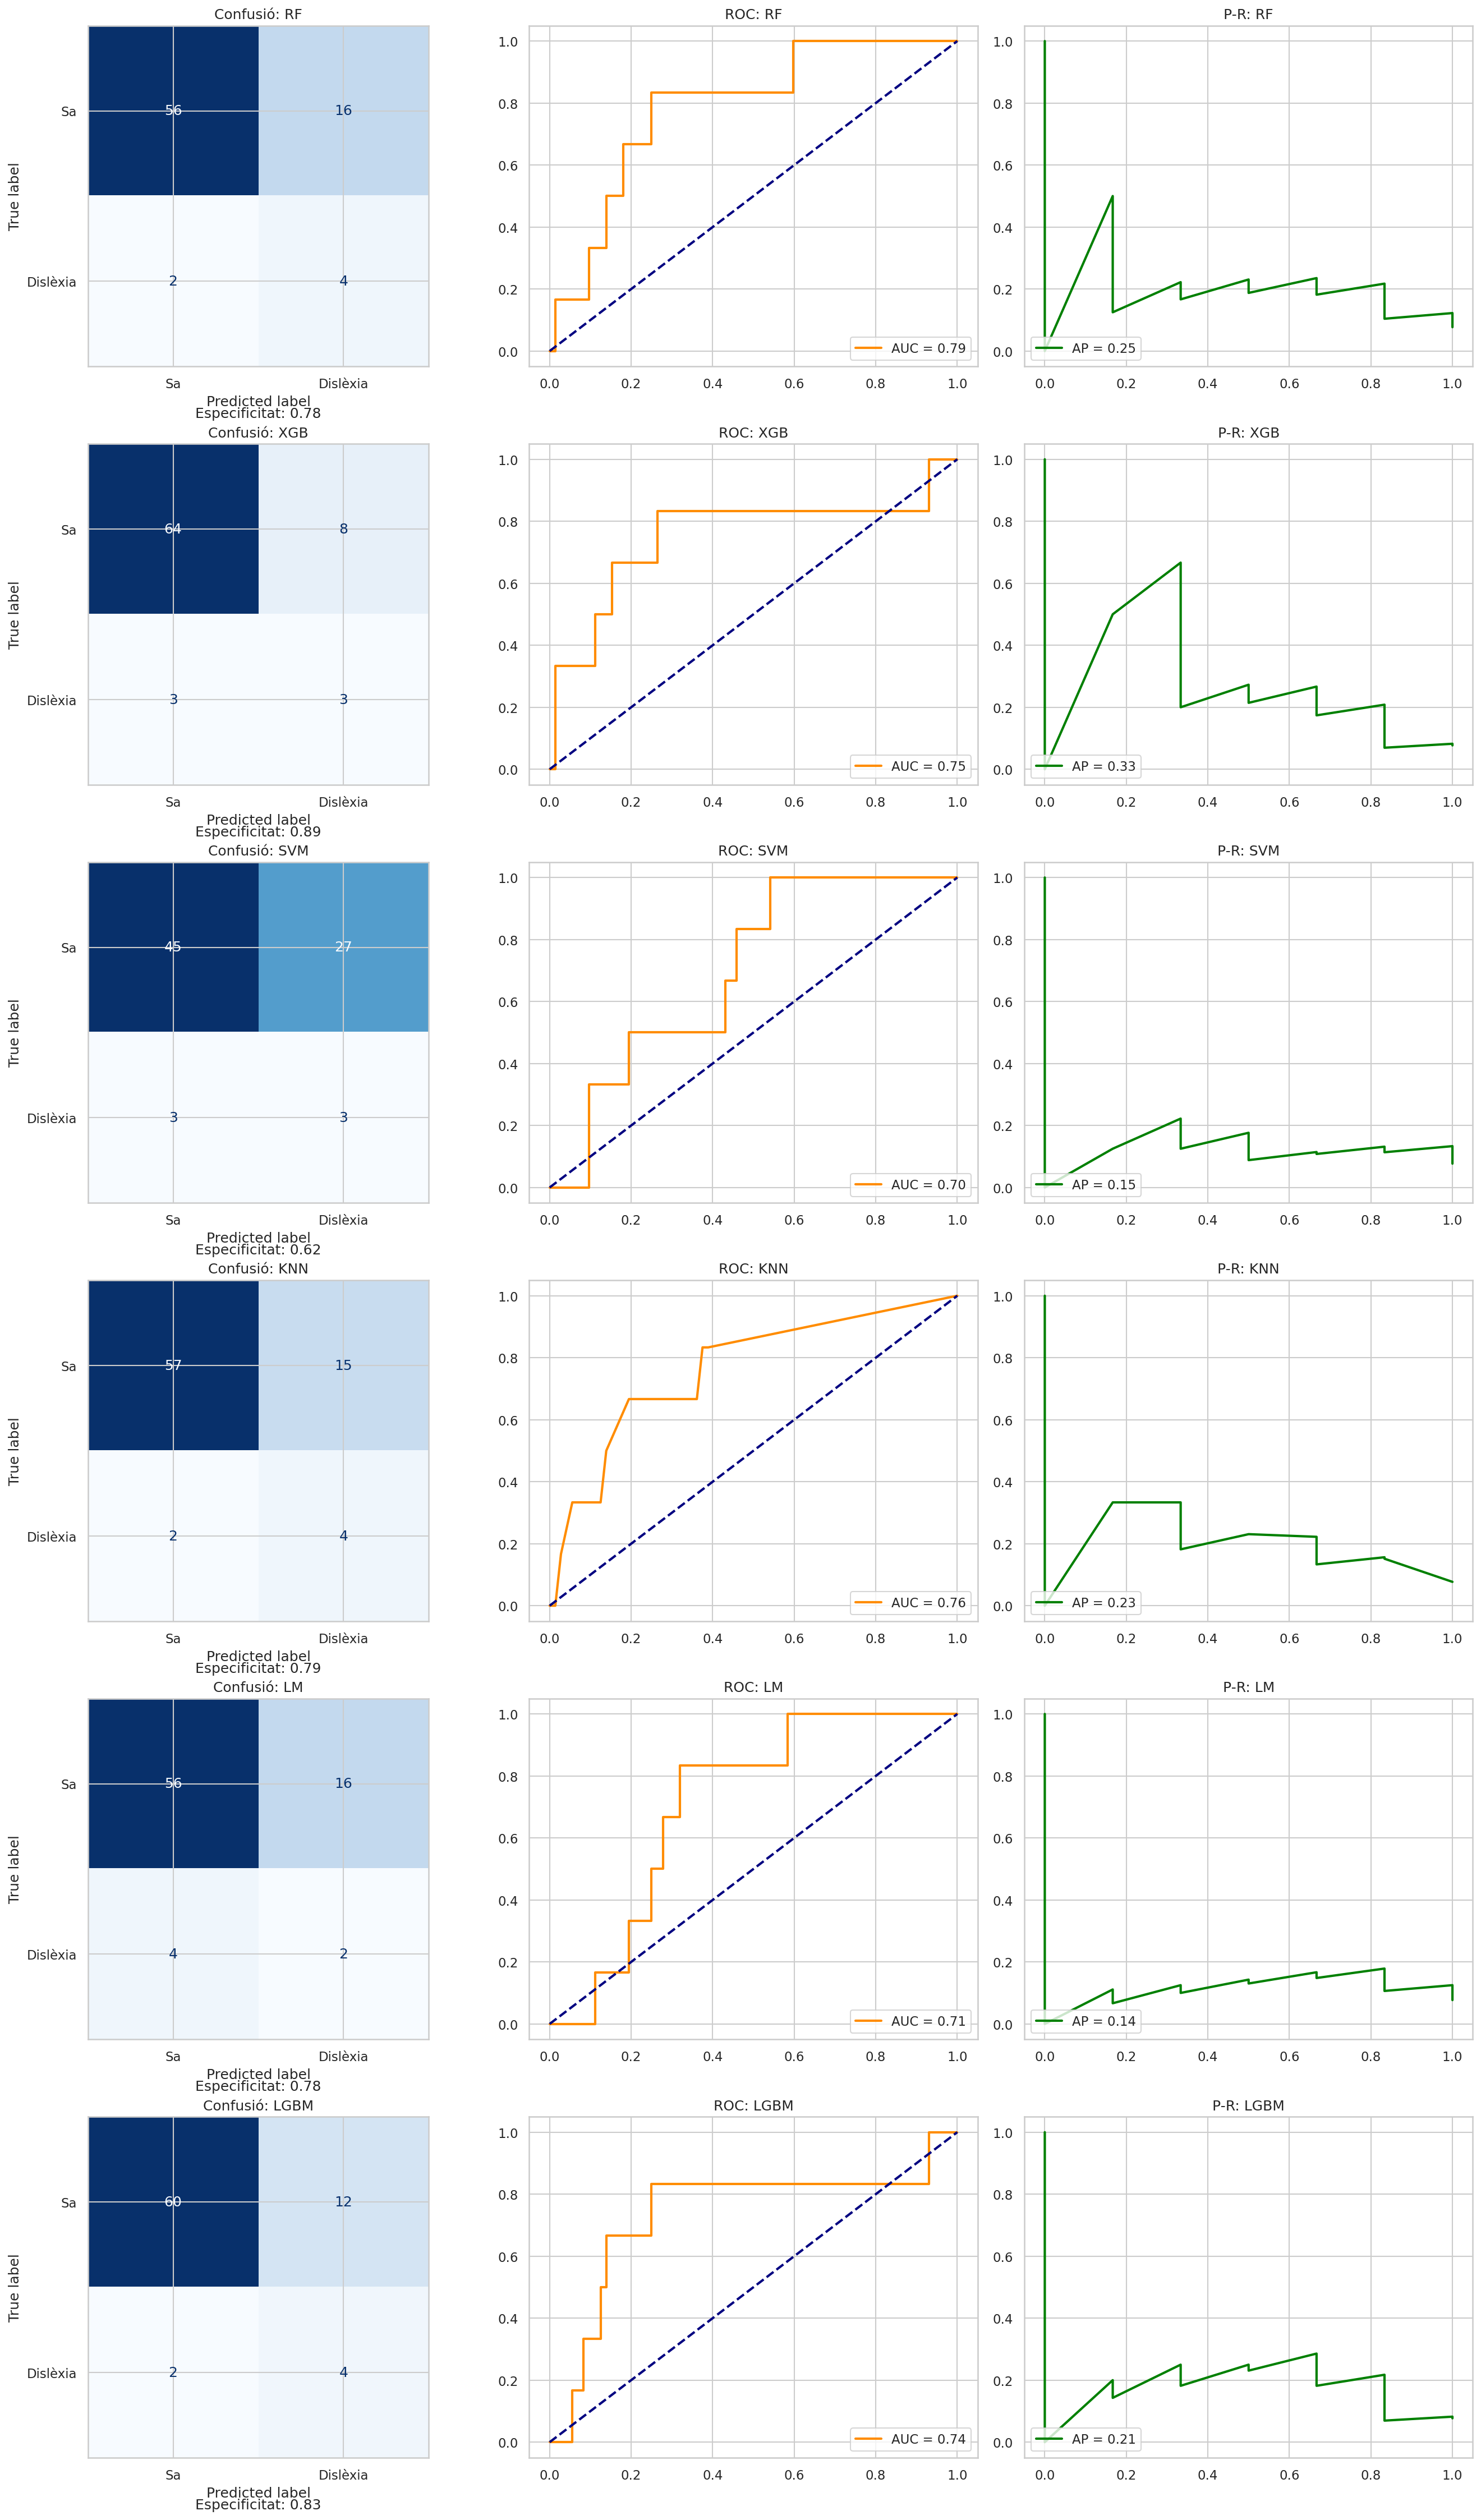

In [ ]:
training_5.plot_metrics()

## 3 Approach b

In [ ]:
import os
import numpy as np
import librosa

def extract_mfcc_features(audio_path, sr=16000, n_mfcc=20):
    y, sr = librosa.load(audio_path, sr=sr)
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc
    )

    mfcc_mean = np.mean(mfcc, axis=1)

    return mfcc_mean

In [ ]:
columness=[col for col in df.columns if "emb_" not in col]
df_aux=df[columness]
print(df_aux.columns)

Index(['arxiu', 'confianca_mitjana', 'confianca_std', 'ritme_std', 'silencis',
       'cer', 'wer', 'velocitat', 'ratio', 'curs', 'dislexia', 'lm_',
       'stratification'],
      dtype='object')


In [ ]:
df_3=df[['arxiu', 'confianca_mitjana', 'confianca_std', 'ritme_std', 'silencis',
       'cer', 'wer', 'velocitat', 'ratio', 'curs', 'dislexia', 'lm_']]
df_3["mfcc"] = None

for idx,row in df_3.iterrows():
  mfcc=extract_mfcc_features(row['arxiu'])
  df_3.at[idx,'mfcc']=mfcc
mfcc_df=pd.DataFrame(df_3["mfcc"].tolist(), index=df_3.index)
mfcc_df.columns=[f"mfcc_{i}" for i in range (mfcc_df.shape[1])]
df_3=pd.concat([df_3,mfcc_df],axis=1)
df_3=df_3.drop(columns=["mfcc"])
df_3.head(10)

,arxiu,confianca_mitjana,confianca_std,ritme_std,silencis,cer,wer,velocitat,ratio,curs,...,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19
0,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.708783,8.654803e-02,2.759990,0.017870,0.154762,0.373333,0.746605,1.093333,2,...,-6.256258,-1.818165,-5.257096,-3.610412,-5.169949,-5.317062,-0.900102,-1.002873,4.140926,7.682360
1,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.399684,5.551115e-17,0.687184,0.000000,0.138095,0.253333,2.521289,0.986667,4,...,-12.443676,-0.504982,-12.239268,-6.208575,-6.224526,-3.901893,-2.805760,-0.678188,-0.847332,5.343679
2,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.260362,6.503376e-02,3.201562,0.000000,0.085714,0.133333,1.386407,1.053333,4,...,-3.141985,-5.432086,-5.951622,-3.555087,-5.610679,-2.003268,-4.595030,0.659306,0.152310,0.114665
3,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.243936,2.054560e-02,8.377798,0.016129,0.042857,0.093333,1.219466,1.013333,2,...,-1.486131,0.551285,-4.235983,-2.175653,-4.093330,-3.037386,-0.911400,-0.573127,2.756414,5.240478
4,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.207233,2.529987e-02,2.134375,0.000000,0.071429,0.160000,1.841493,1.000000,4,...,-9.095657,-5.711437,-1.154436,-9.582877,-1.549029,-1.007380,-1.859361,-0.186342,-0.771190,2.682152
5,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.226146,1.813243e-02,1.195229,0.000000,0.042857,0.080000,1.745935,1.000000,4,...,-6.056518,-3.102059,-8.314699,-3.747587,-4.763002,-9.473347,-10.964231,-0.373384,-7.643602,0.520239
6,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.550943,2.903898e-01,11.578394,0.024486,0.150000,0.266667,0.991580,1.080000,2,...,-4.081423,-2.142918,-3.008287,-4.236495,-4.306840,-5.199516,-3.500830,-1.387199,-0.112875,5.868332
7,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.450558,1.778927e-03,1.030158,0.000000,0.128571,0.293333,1.888659,1.013333,4,...,-5.954296,-1.096825,-5.643596,-3.873437,-4.425750,-4.843727,-4.598961,-3.154917,-2.830652,1.104272
8,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.375613,3.639527e-02,1.606207,0.010776,0.066667,0.146667,1.988092,0.986667,3,...,-4.678249,0.078132,-6.576062,-5.570374,-4.731987,-7.997116,-3.701227,0.859575,0.245929,5.517494
9,/content/drive/MyDrive/TFG/audios_castella_uni...,-0.243850,1.067812e-01,3.685557,0.000000,0.116667,0.200000,1.579357,1.093333,3,...,-1.501265,-4.820685,-3.826047,-4.328059,-5.620147,-7.048767,-4.599434,-1.983482,-3.753582,2.811636


In [ ]:
columns_no_train=["arxiu","dislexia","stratification"]
X_train,X_test,y_train,y_test=split(df_3,columns_no_train)
print(X_train)

     confianca_mitjana  confianca_std  ritme_std      silencis       cer  \
35           -0.443560       0.070499   2.942176 -1.983648e-16  0.085714   
58           -0.413668       0.075484   2.022375  0.000000e+00  0.185714   
7            -0.450558       0.001779   1.030158  0.000000e+00  0.128571   
151          -0.351517       0.015119   1.811636  0.000000e+00  0.119048   
369          -2.904549       1.579885   7.534016  1.888925e-02  0.469048   
..                 ...            ...        ...           ...       ...   
323          -0.600128       0.089086   6.251272  3.589375e-04  0.159524   
311          -0.513748       0.011464   1.500000  0.000000e+00  0.154762   
270          -0.657354       0.145164   2.160247  0.000000e+00  0.283333   
30           -0.424505       0.111004   4.088641  8.908686e-03  0.130952   
81           -0.348980       0.159948   1.771691  0.000000e+00  0.111905   

          wer  velocitat     ratio curs  lm_  ...    mfcc_10   mfcc_11  \
35   0.186667

In [ ]:
columns_to_normalize_mfcc=columns_to_normalize_not_emb+[column for column in df_3.columns if "mfcc" in column]
preprocessor3=ColumnTransformer(
    transformers=[
        ("scaler",StandardScaler(),columns_to_normalize_mfcc)
    ],
    remainder="passthrough"
)

pipeline4=Pipeline([
    ('smote',SMOTENC(categorical_features=categorical_index,random_state=42)),
    ('prep',preprocessor3),
    ('model', rf)
])

In [ ]:
training_6=Training(X_train,y_train,X_test,y_test)
entrenament=training_6.entrenament(pipeline4, dict_models, scoring,params_grid,cv)

Entrenant rf
Fitting 15 folds for each of 48 candidates, totalling 720 fits
Entrenant xgb
Fitting 15 folds for each of 216 candidates, totalling 3240 fits
Entrenant svm
Fitting 15 folds for each of 32 candidates, totalling 480 fits
Entrenant knn
Fitting 15 folds for each of 20 candidates, totalling 300 fits
Entrenant lm
Fitting 15 folds for each of 20 candidates, totalling 300 fits
Entrenant lgbm
Fitting 15 folds for each of 81 candidates, totalling 1215 fits
[LightGBM] [Info] Number of positive: 286, number of negative: 286
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5199
[LightGBM] [Info] Number of data points in the train set: 572, number of used features: 30
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [ ]:
training_6.print_results()

Model: rf
Best hiperparameters: {'model__class_weight': None, 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best mean F1 in CV: 0.37870962370962374 ± 0.1728210373903114
Best mean Recall in CV: 0.49000000000000005 ± 0.245085019262024
Best mean Precision in CV: 0.3242520442520443 ± 0.16760420217263552
Classification report test de rf               precision    recall  f1-score   support

           0       0.94      0.93      0.94        72
           1       0.29      0.33      0.31         6

    accuracy                           0.88        78
   macro avg       0.61      0.63      0.62        78
weighted avg       0.89      0.88      0.89        78

Classification report train de rf               precision    recall  f1-score   support

           0       1.00      0.93      0.97       286
           1       0.56      1.00      0.72        24

    accuracy                           0.94 

In [ ]:
training_6.print_results_profund()

ANALITZANT MODEL: RF

 RECALL: Detectats 2 de 6 nens amb dislexia.

 PRECISSION: 2 dislexics eren reals dels 7 predits.

Detalle de los niños con dislexia:
     Realidad  Prediccion  Prob_Dislexia  Error
31          1           0       0.357759   True
269         1           0       0.132722   True
340         1           1       0.649483  False
166         1           0       0.000614   True
130         1           0       0.218562   True
157         1           1       0.639918  False
     Realidad  Prediccion  Prob_Dislexia  Error
6           0           1       0.545509   True
158         0           1       0.713293   True
340         1           1       0.649483  False
377         0           1       0.641191   True
157         1           1       0.639918  False
121         0           1       0.520389   True
21          0           1       0.696485   True
ANALITZANT MODEL: XGB

 RECALL: Detectats 2 de 6 nens amb dislexia.

 PRECISSION: 2 dislexics eren reals dels 7 predits.

De

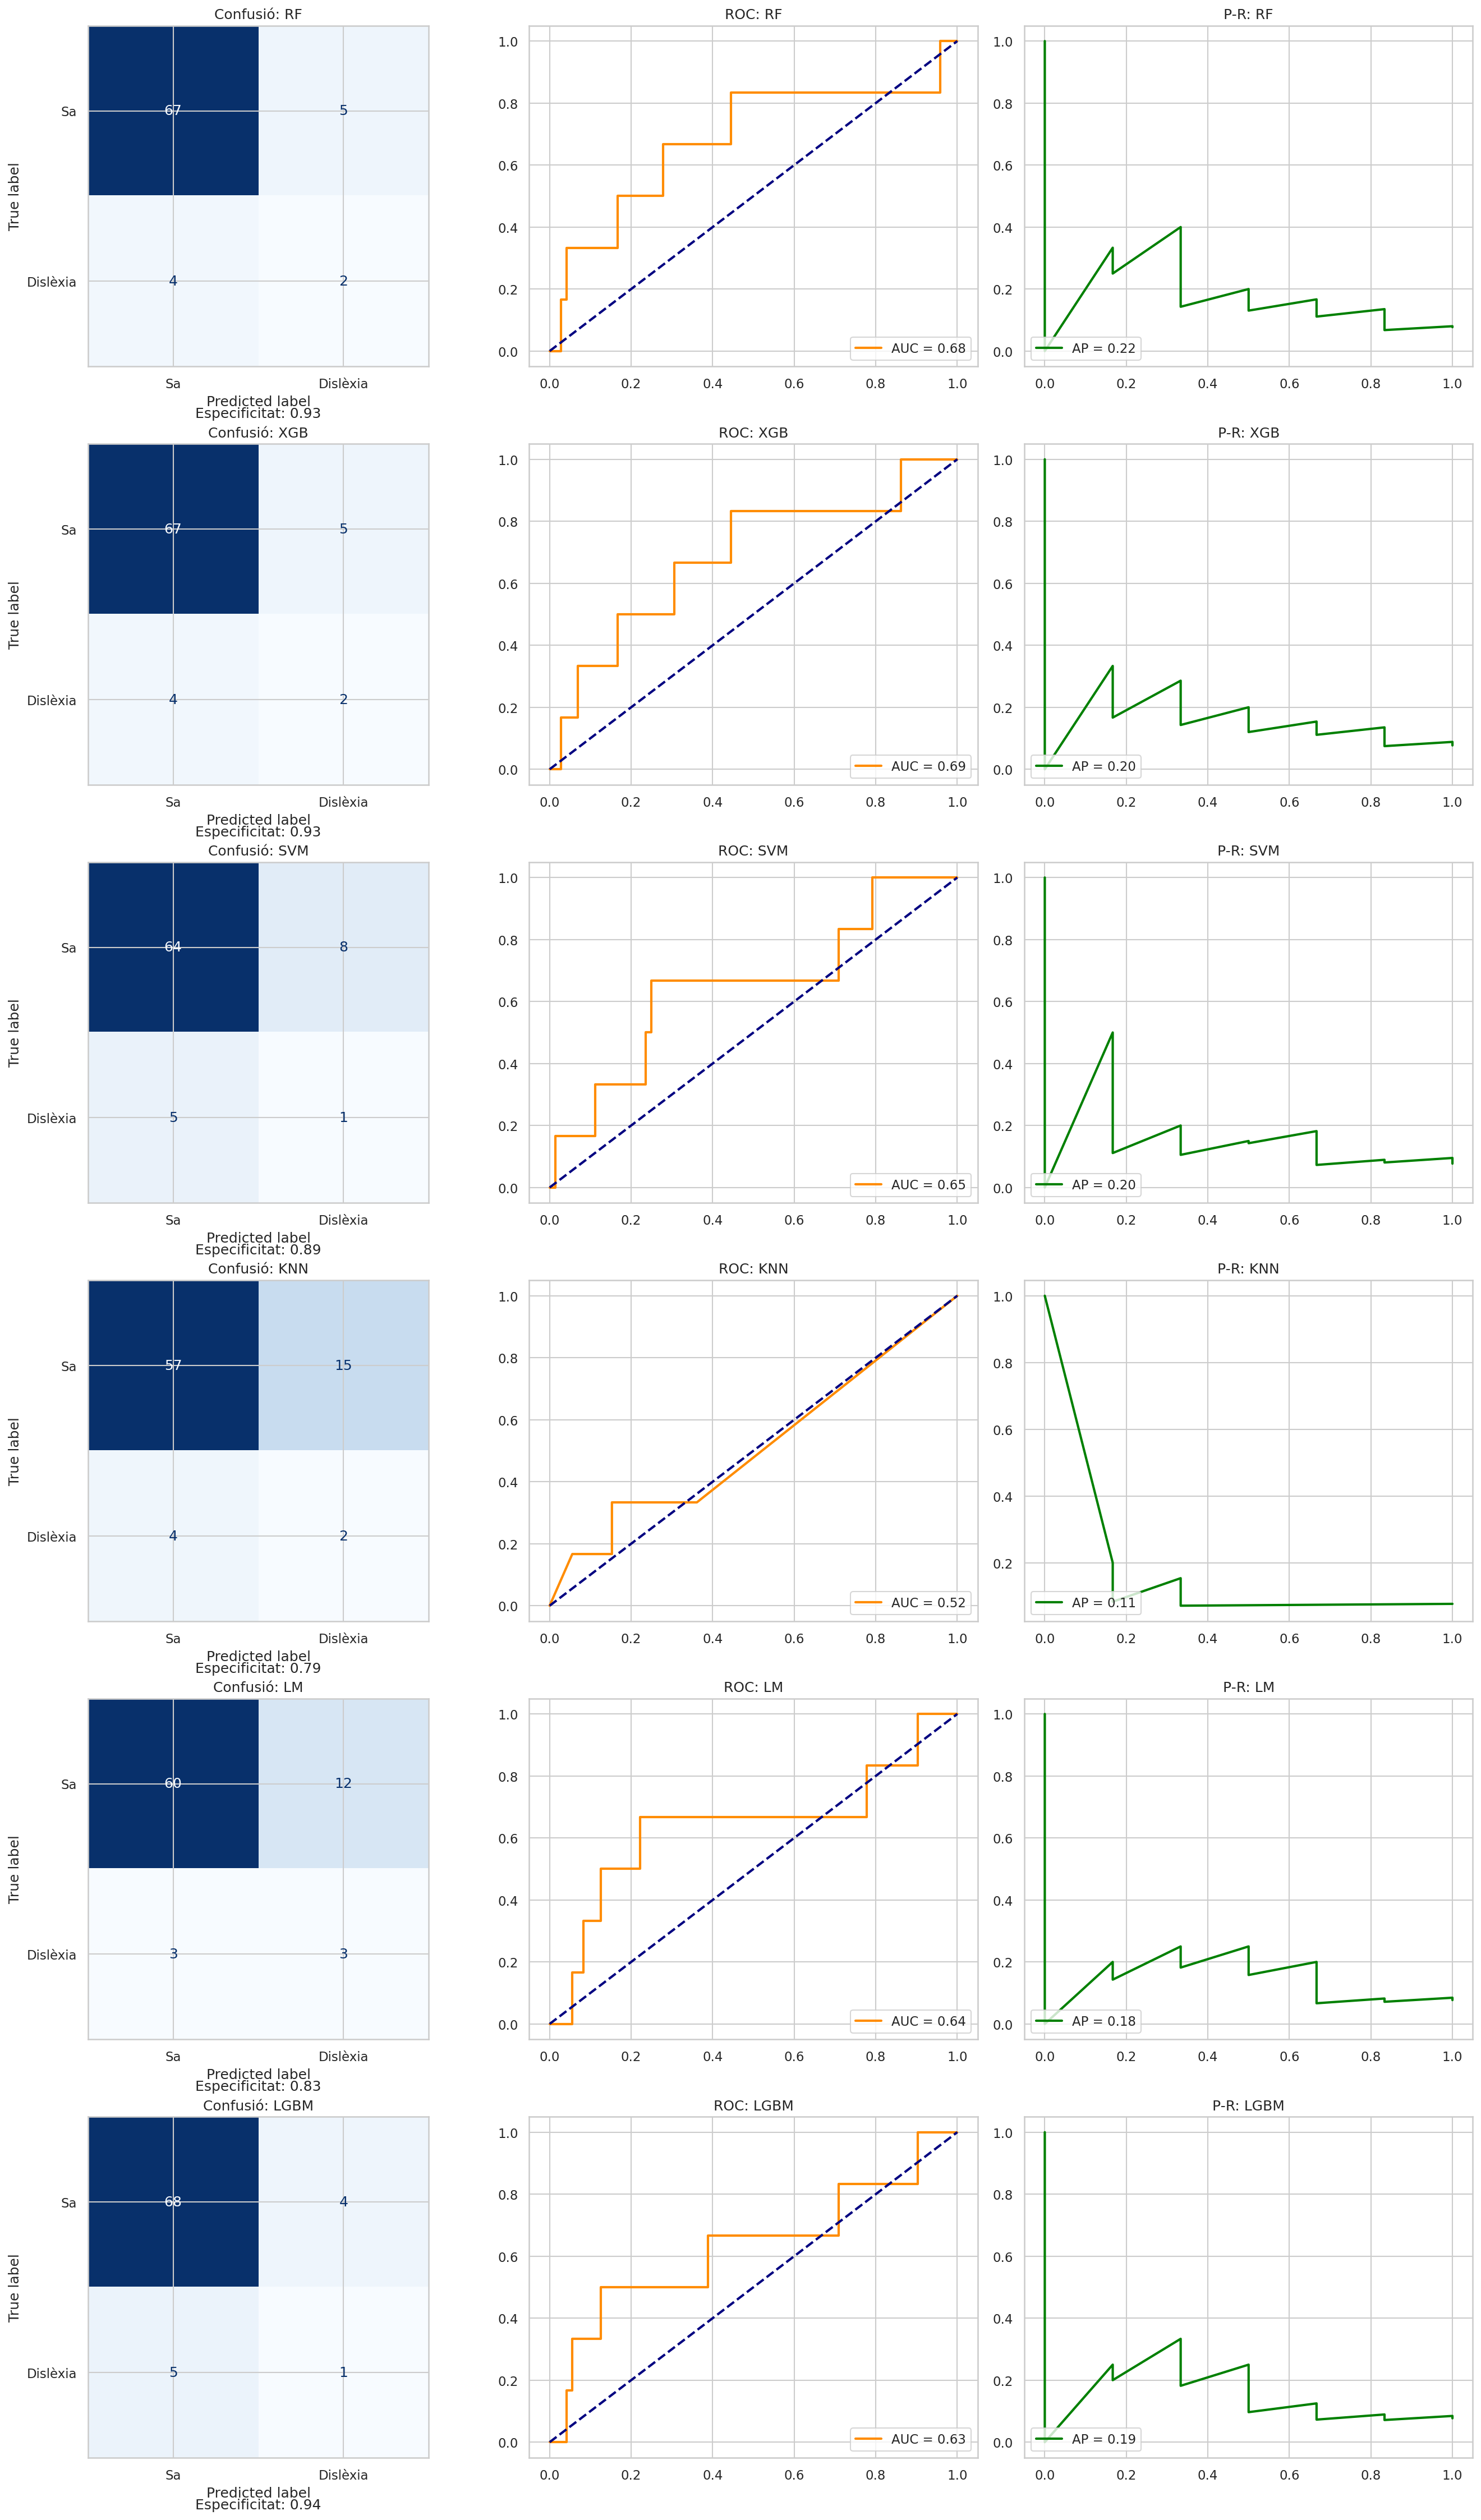

In [ ]:
training_6.plot_metrics()